# Performance Evaluation

CSI 4106 - Fall 2026

Marcel Turcotte  
Version: Sep 24, 2026 14:39

# Preamble

## Message of the Day

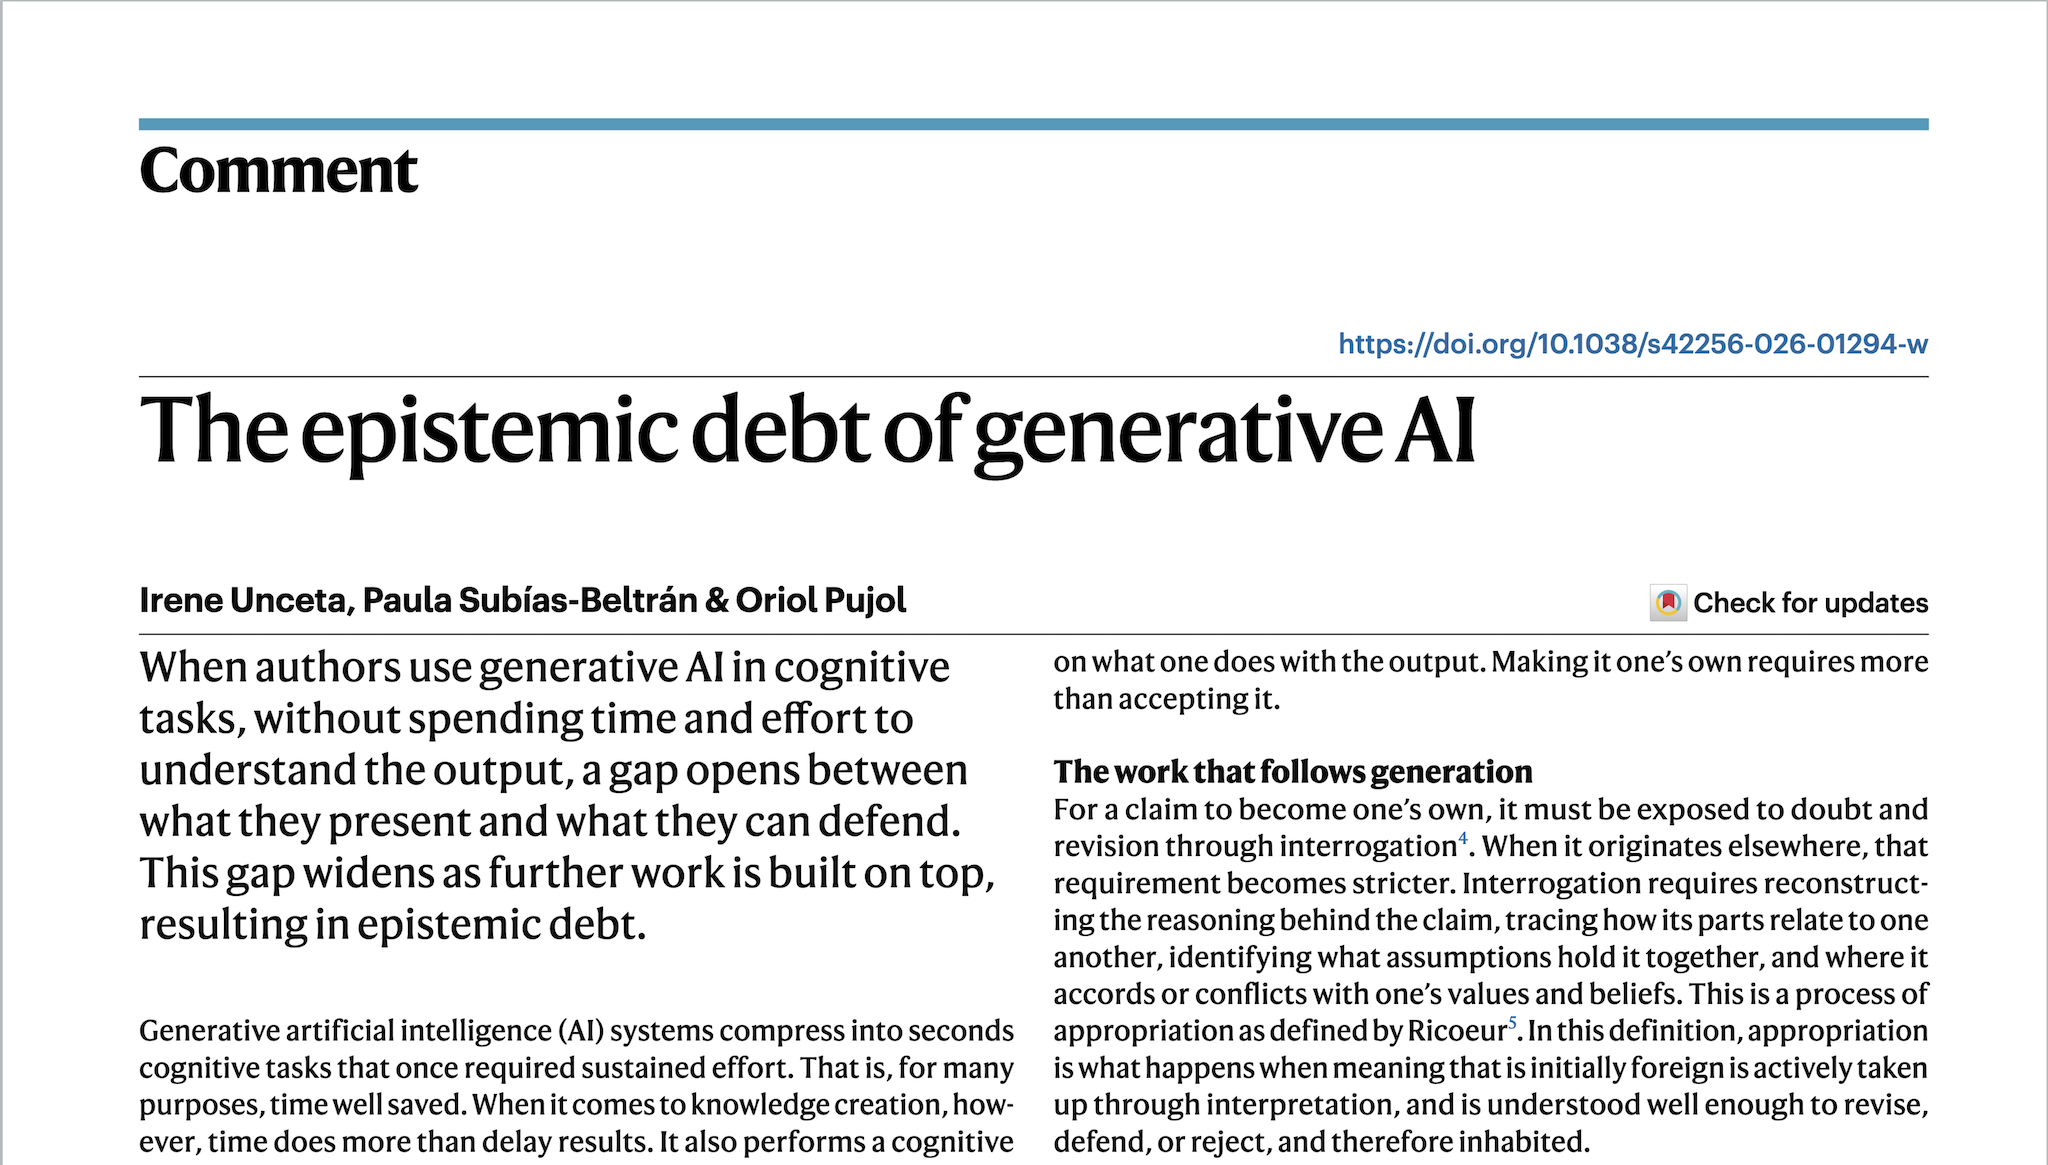

Unceta et al. (2026),
<a href="https://www.nature.com/articles/s42256-026-01294-w"
class="external"
data-icon="true">www.nature.com/articles/s42256-026-01294-w</a>

>  **(Unceta et al. 2026)**
>
> When authors use generative AI in cognitive tasks, without spending
> time and effort to understand the output, a gap opens between what
> they present and what they can defend. This gap widens as further work
> is built on top, resulting in epistemic debt.

You have full access to this article when connected through a uOttawa IP
address.

## Lecture overview

This lecture develops **classification evaluation** from the **confusion
matrix**. It introduces **accuracy**, **precision**, **recall**, and the
**$F_1$ score**, then examines **class imbalance** and **micro** versus
**macro** averaging. The final sections connect **decision thresholds**
to **precision-recall** and **ROC curves** and interpret **AUROC** as a
measure of score ranking.

## Learning Objectives

- **Derive** binary and one-vs-rest counts from a confusion matrix.
- **Compute** and **interpret** accuracy, precision, recall, and the
  $F_1$ score.
- **Explain** why class imbalance can make accuracy misleading.
- **Compare** micro and macro averaging for multiclass metrics.
- **Relate** a decision threshold to precision, recall, and an ROC
  operating point.
- **Construct** an ROC curve from classifier scores and **interpret**
  AUROC as a ranking measure.

# Performance Metrics

## Confusion Matrix

|  | **Positive** (**Predicted**) | **Negative** (**Predicted**) |
|------------------------|------------------------|------------------------|
| **Positive** (**Actual**) | True positive (TP) | False negative (FN) |
| **Negative** (**Actual**) | False positive (FP) | True negative (TN) |

A **confusion matrix** is a table summarizing the performance of a
classification algorithm (here for a binary classification task).

- In statistical analysis, **False Positives (FP)** are commonly
  referred to as **Type I errors**, and **False Negatives (FN)** are
  known as **Type II errors**.
- The diagonal elements represent the correctly predicted outcomes,
  namely true positives (TP) and true negatives (TN).
- In contrast, the off-diagonal elements correspond to incorrect
  predictions, specifically false positives (FP) and false negatives
  (FN).
- The **confusion matrix** contains the counts needed to assess a
  classification model.
- While the confusion matrix provides a comprehensive view, more
  **concise metrics** such as **accuracy**, **precision**, **recall**,
  and the **F$_1$ score** are often more intuitive and practical for
  summarizing model performance.

## ConfusionMatrixDisplay

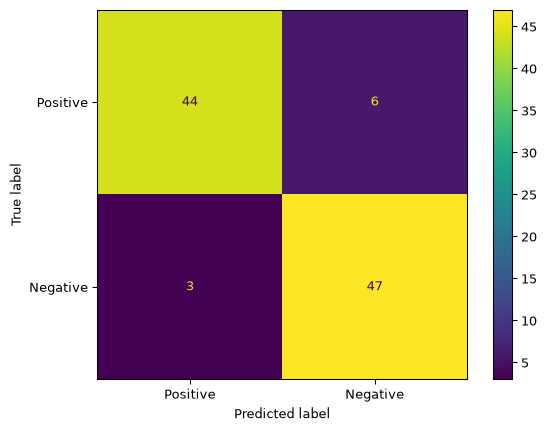

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

seed = 42

X, y = make_classification(n_samples=500, random_state=seed)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)

clf = LogisticRegression(random_state=seed)

clf.fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions, labels=[1, 0])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Positive", "Negative"],
)

disp.plot()
plt.show()

The example uses `make_classification` to generate a synthetic dataset
and fits a `LogisticRegression` model. Passing `labels=[1, 0]` places
the positive class first so that the display matches the table on the
preceding page.

## Confusion Matrix

Given a test set with $N$ examples and a classifier $h(x):$

$$
C_{i,j} = \sum_{k = 1}^N [y_k = i \wedge h(x_k) = j]
$$

Here, $C$ is an $l \times l$ matrix for a dataset with $l$ classes.

A confusion matrix $C$ is defined such that each element $C_{i,j}$
represents the count of observations actually belonging to class $i$ but
predicted to belong to class $j$.

The same definition applies to $l$ classes. Rows represent actual
labels, columns represent predicted labels, and each entry counts one
actual-predicted pairing.

## Confusion Matrix

- The total number of examples of the (**actual**) class $i$ is $$
  C_{i \cdot} = \sum_{j=1}^l C_{i,j}
  $$

- The total number of examples assigned to the (**predicted**) class $j$
  by classifier $h$ is $$
  C_{\cdot j} = \sum_{i=1}^l C_{i,j}
  $$

## Confusion Matrix

- Terms on the **diagonal** denote the total number of examples
  **classified correctly** by classifier $h$. Hence, the number of
  correctly classified examples is $$
  \sum_{i=1}^l C_{i,i}
  $$

- **Non-diagonal** terms represent **misclassifications**.

## Confusion Matrix: Multiclass

For a **multiclass** problem, derive **one-vs-rest** counts for each
class and then combine the resulting class-specific metrics.

## Confusion Matrix: Multiclass

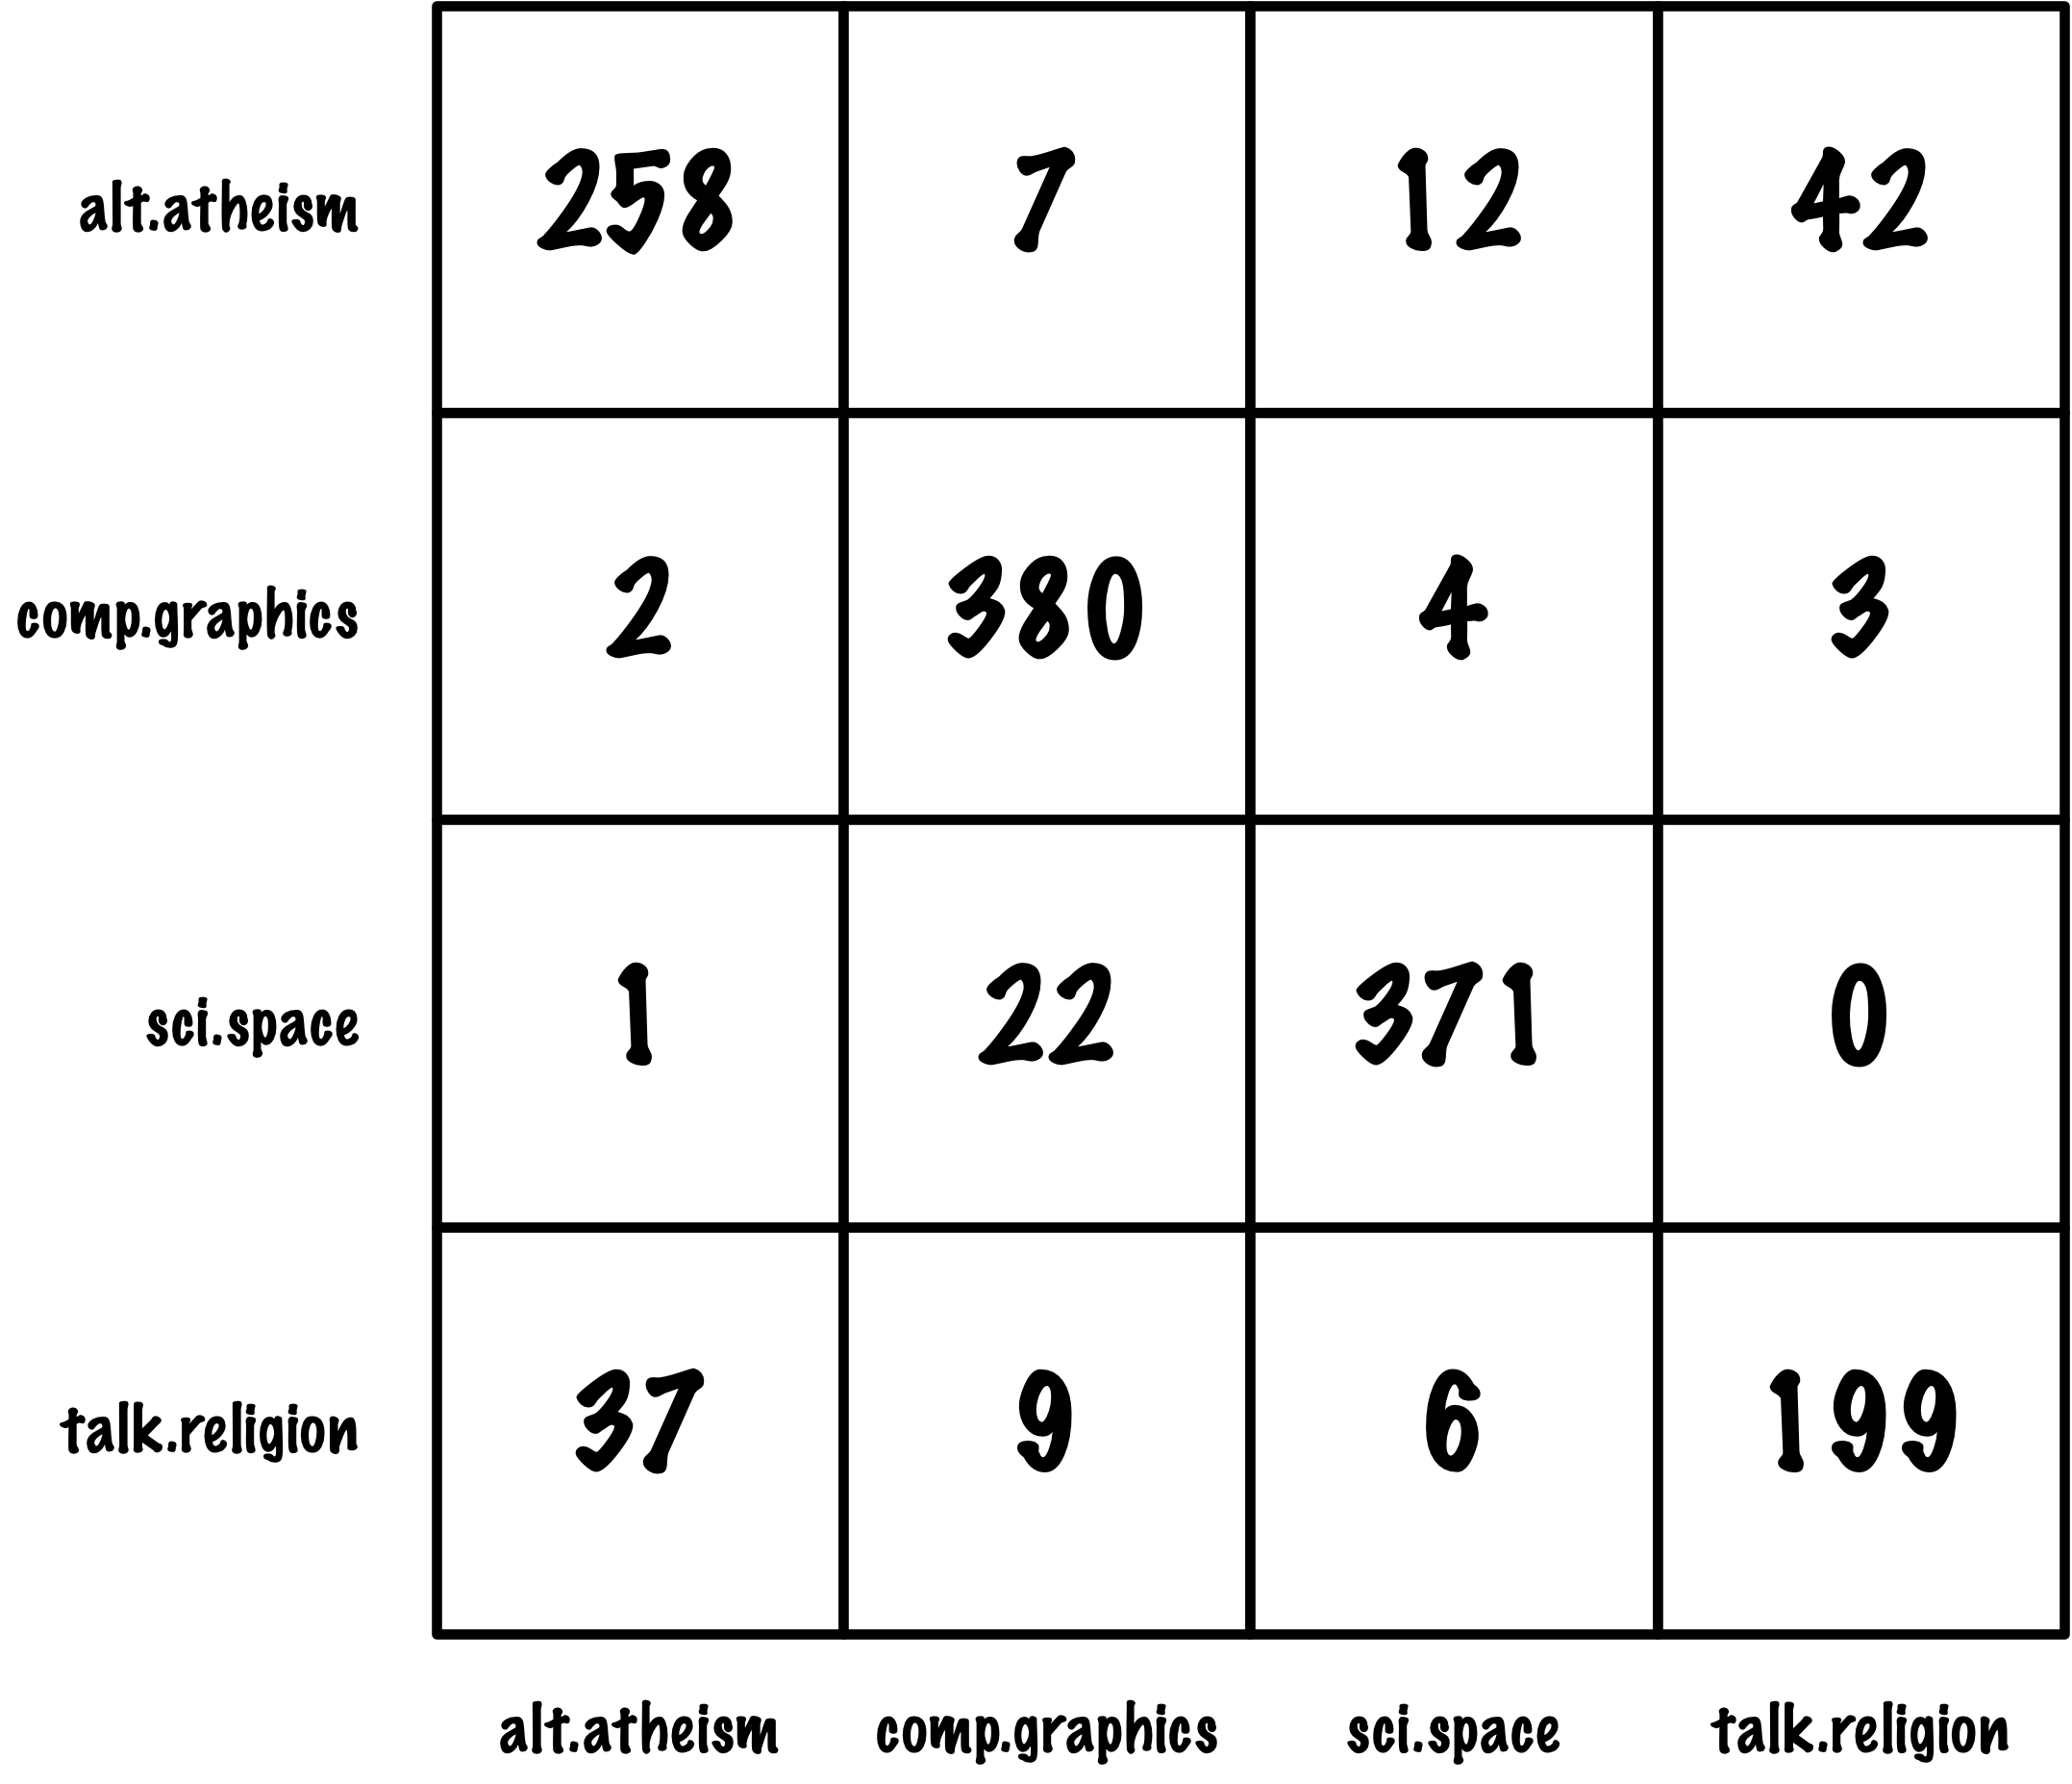

Using data from the <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html#sklearn.datasets.fetch_20newsgroups"
class="external" data-icon="true">20 Newsgroups text dataset</a> from
<a href="https://scikit-learn.org" class="external"
data-icon="true">scikit-learn</a>.

## Confusion Matrix: True Positive

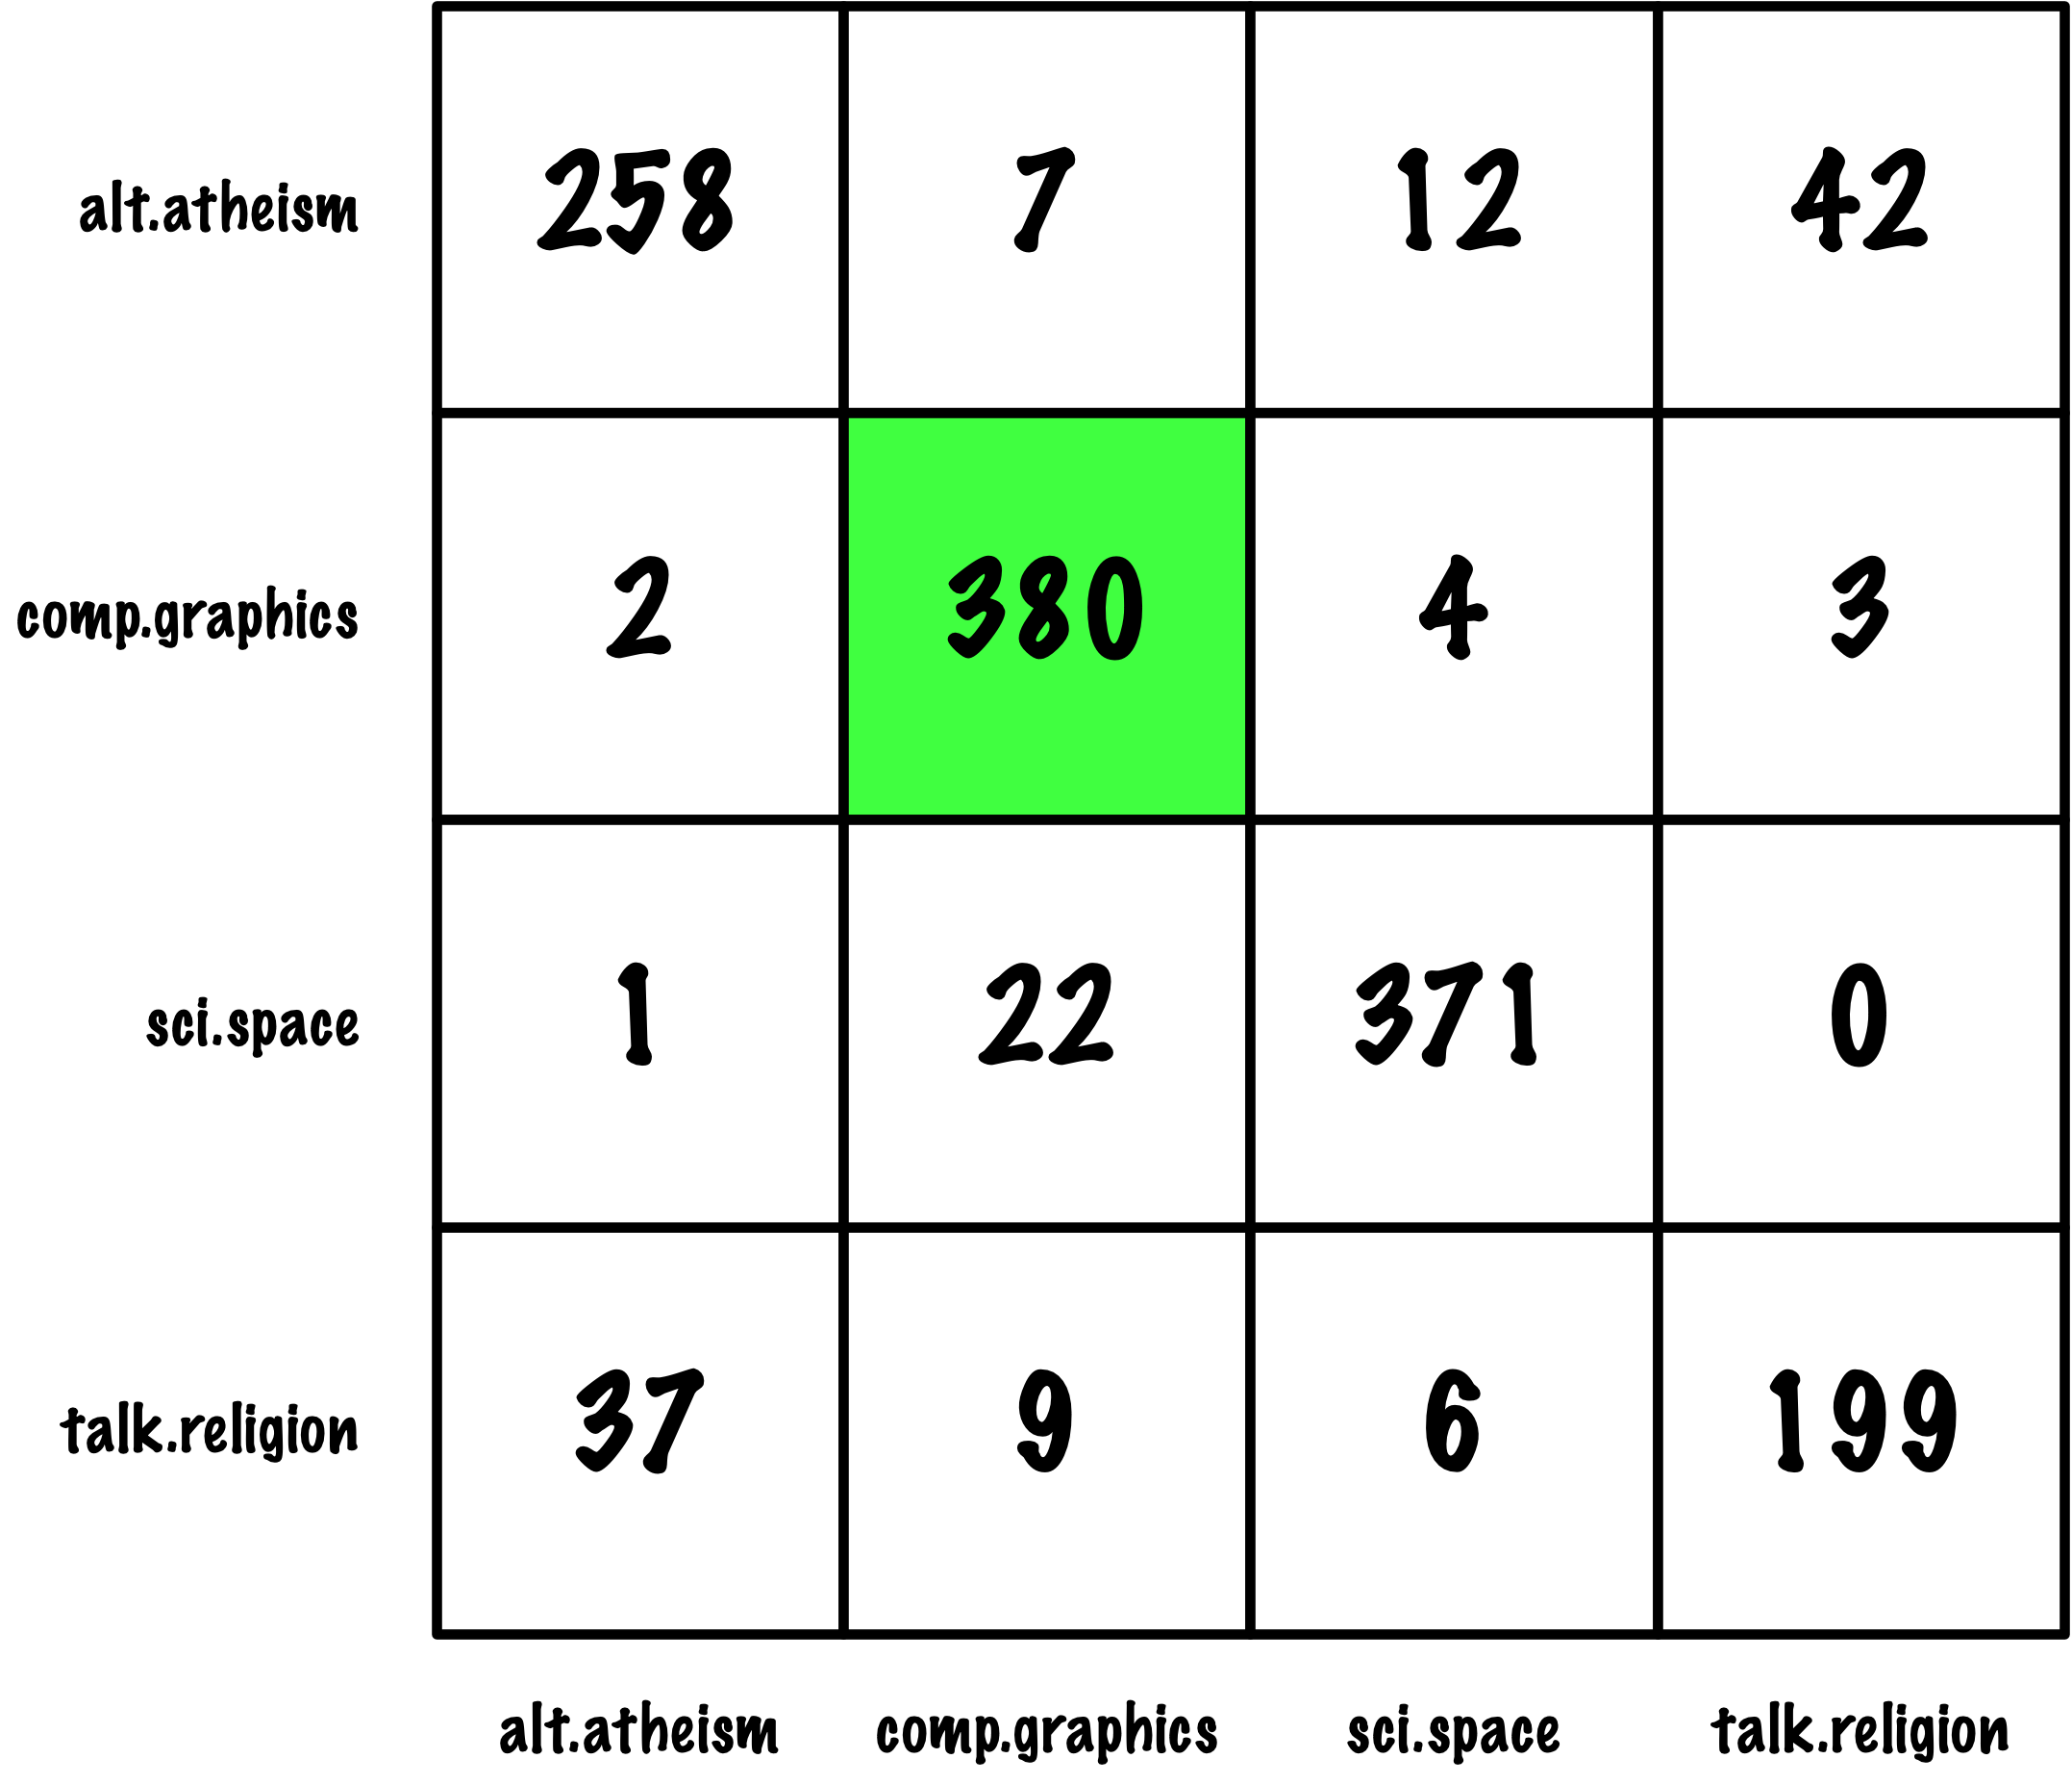

`comp.graphics` is both the **actual** and **predicted** class.

## Confusion Matrix: False Positive

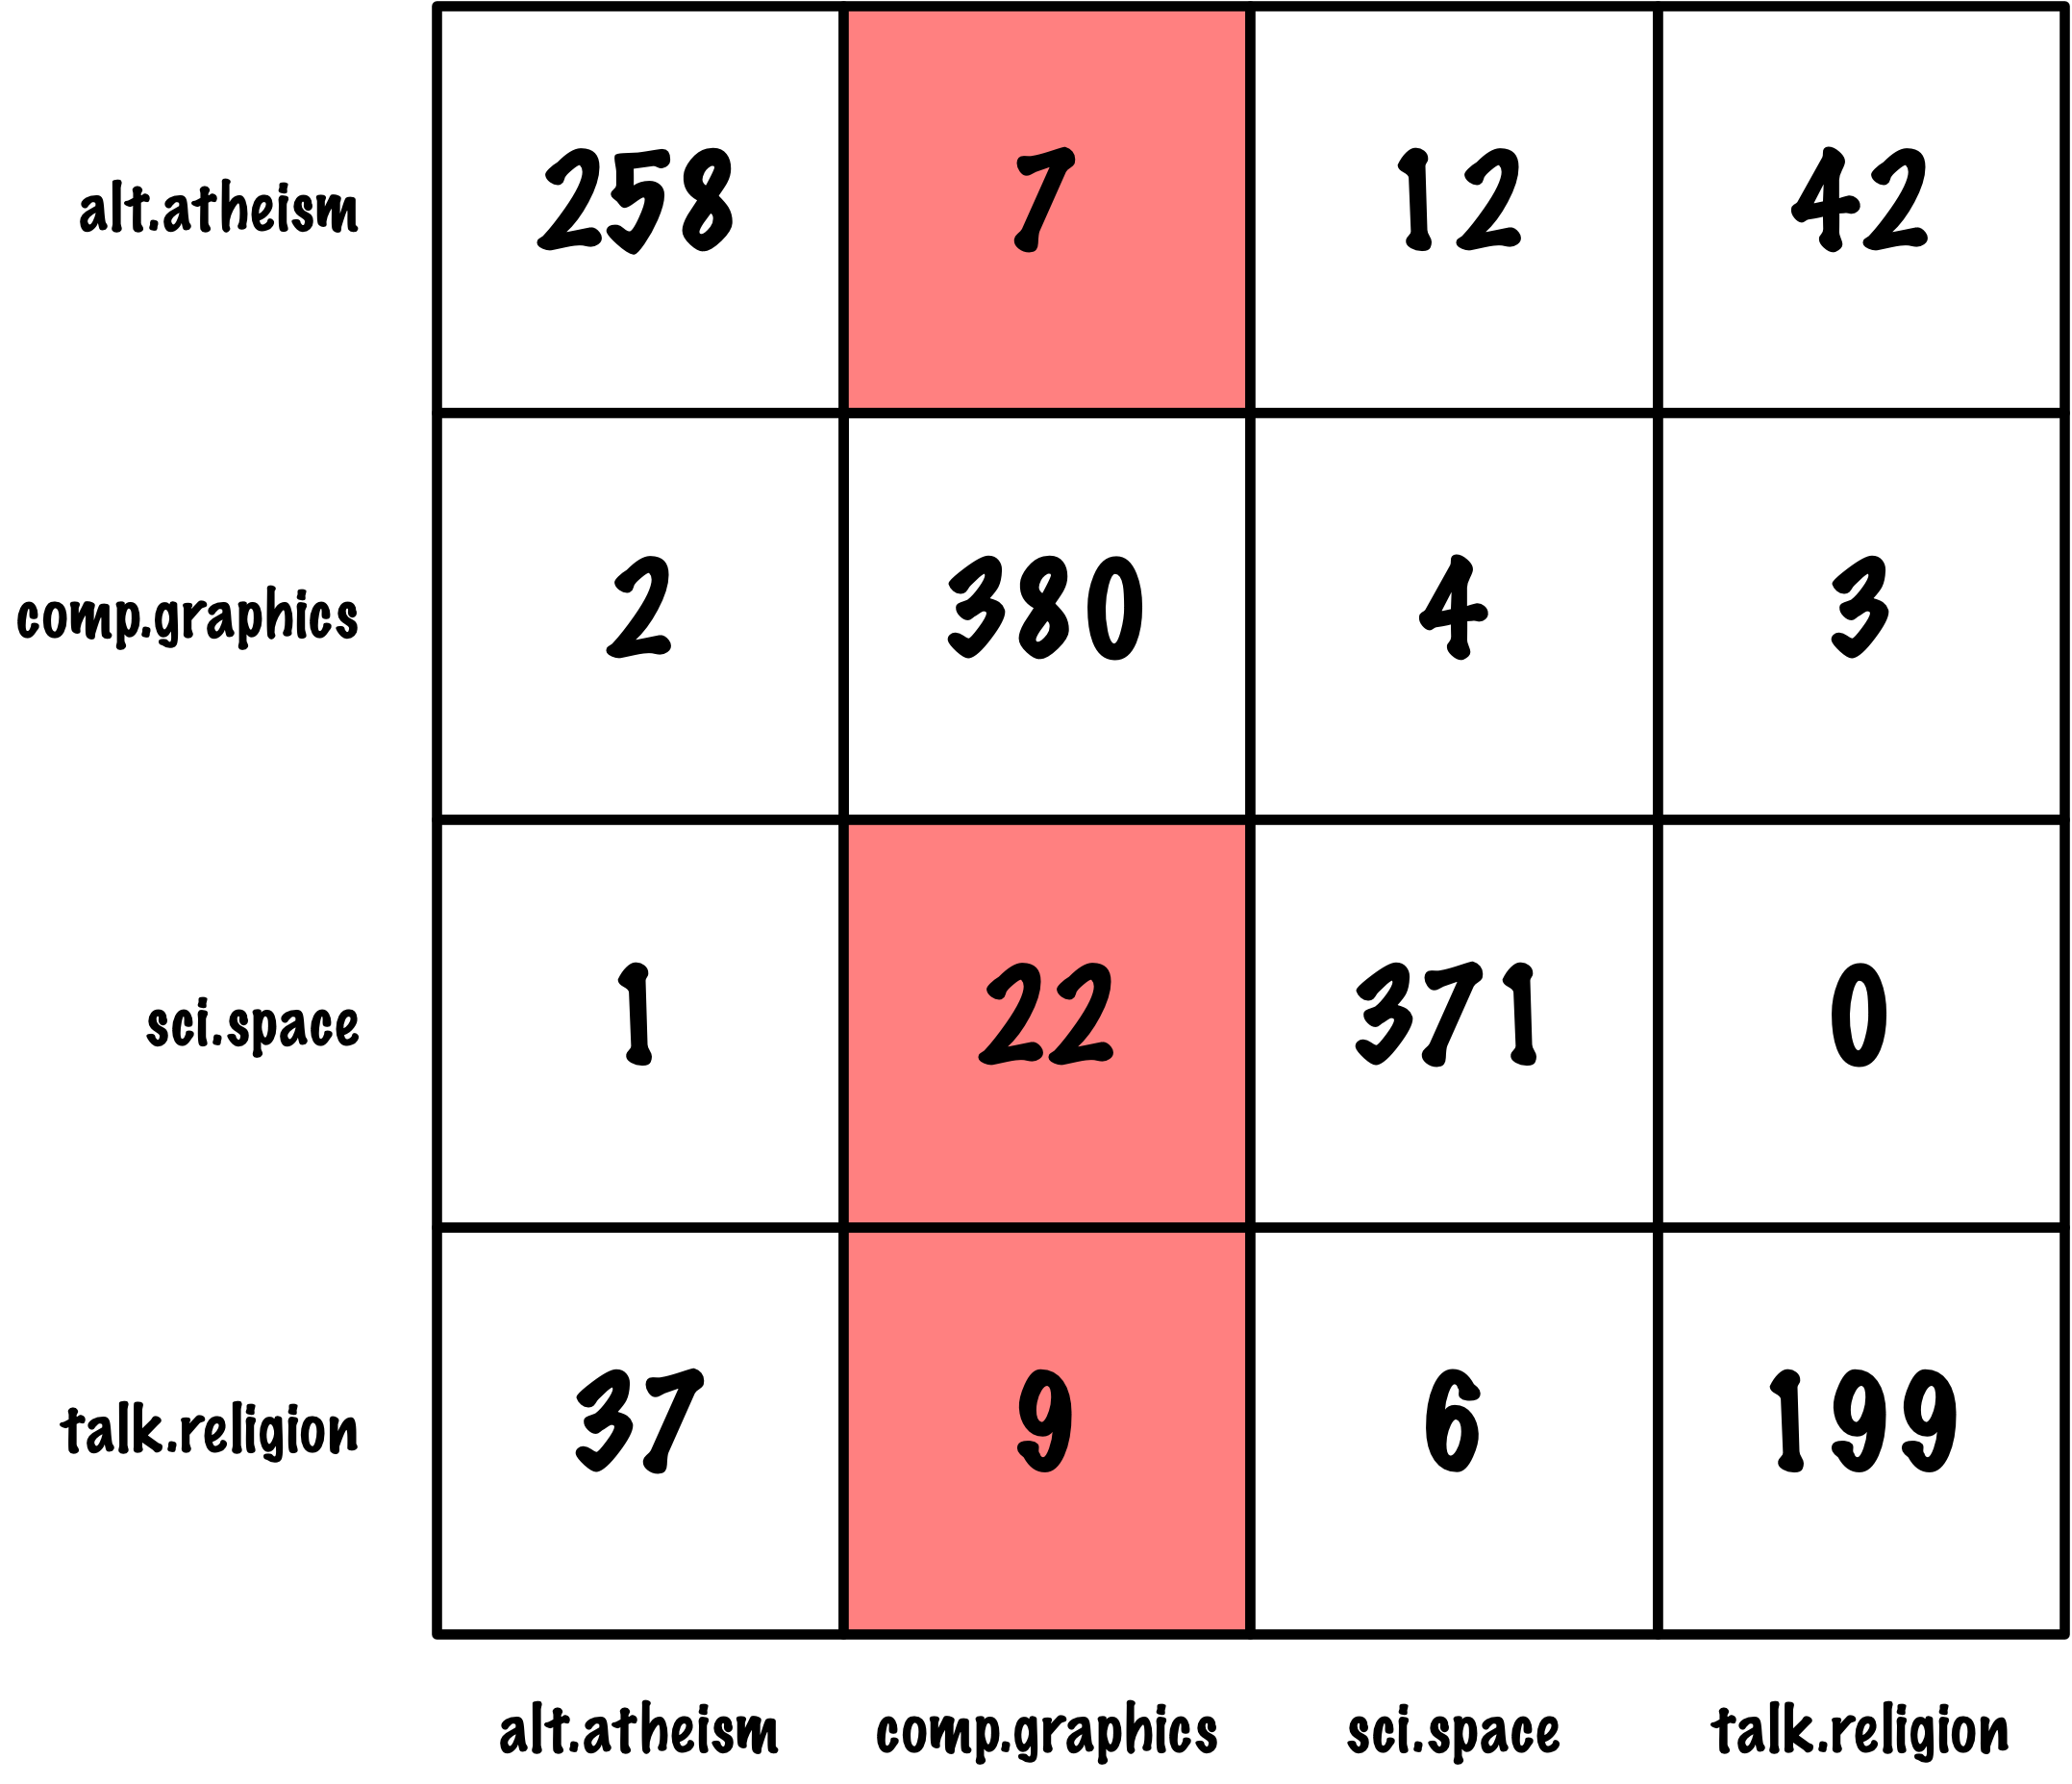

The model predicts `comp.graphics`, but the example belongs to another
class.

## Confusion Matrix: False Negative

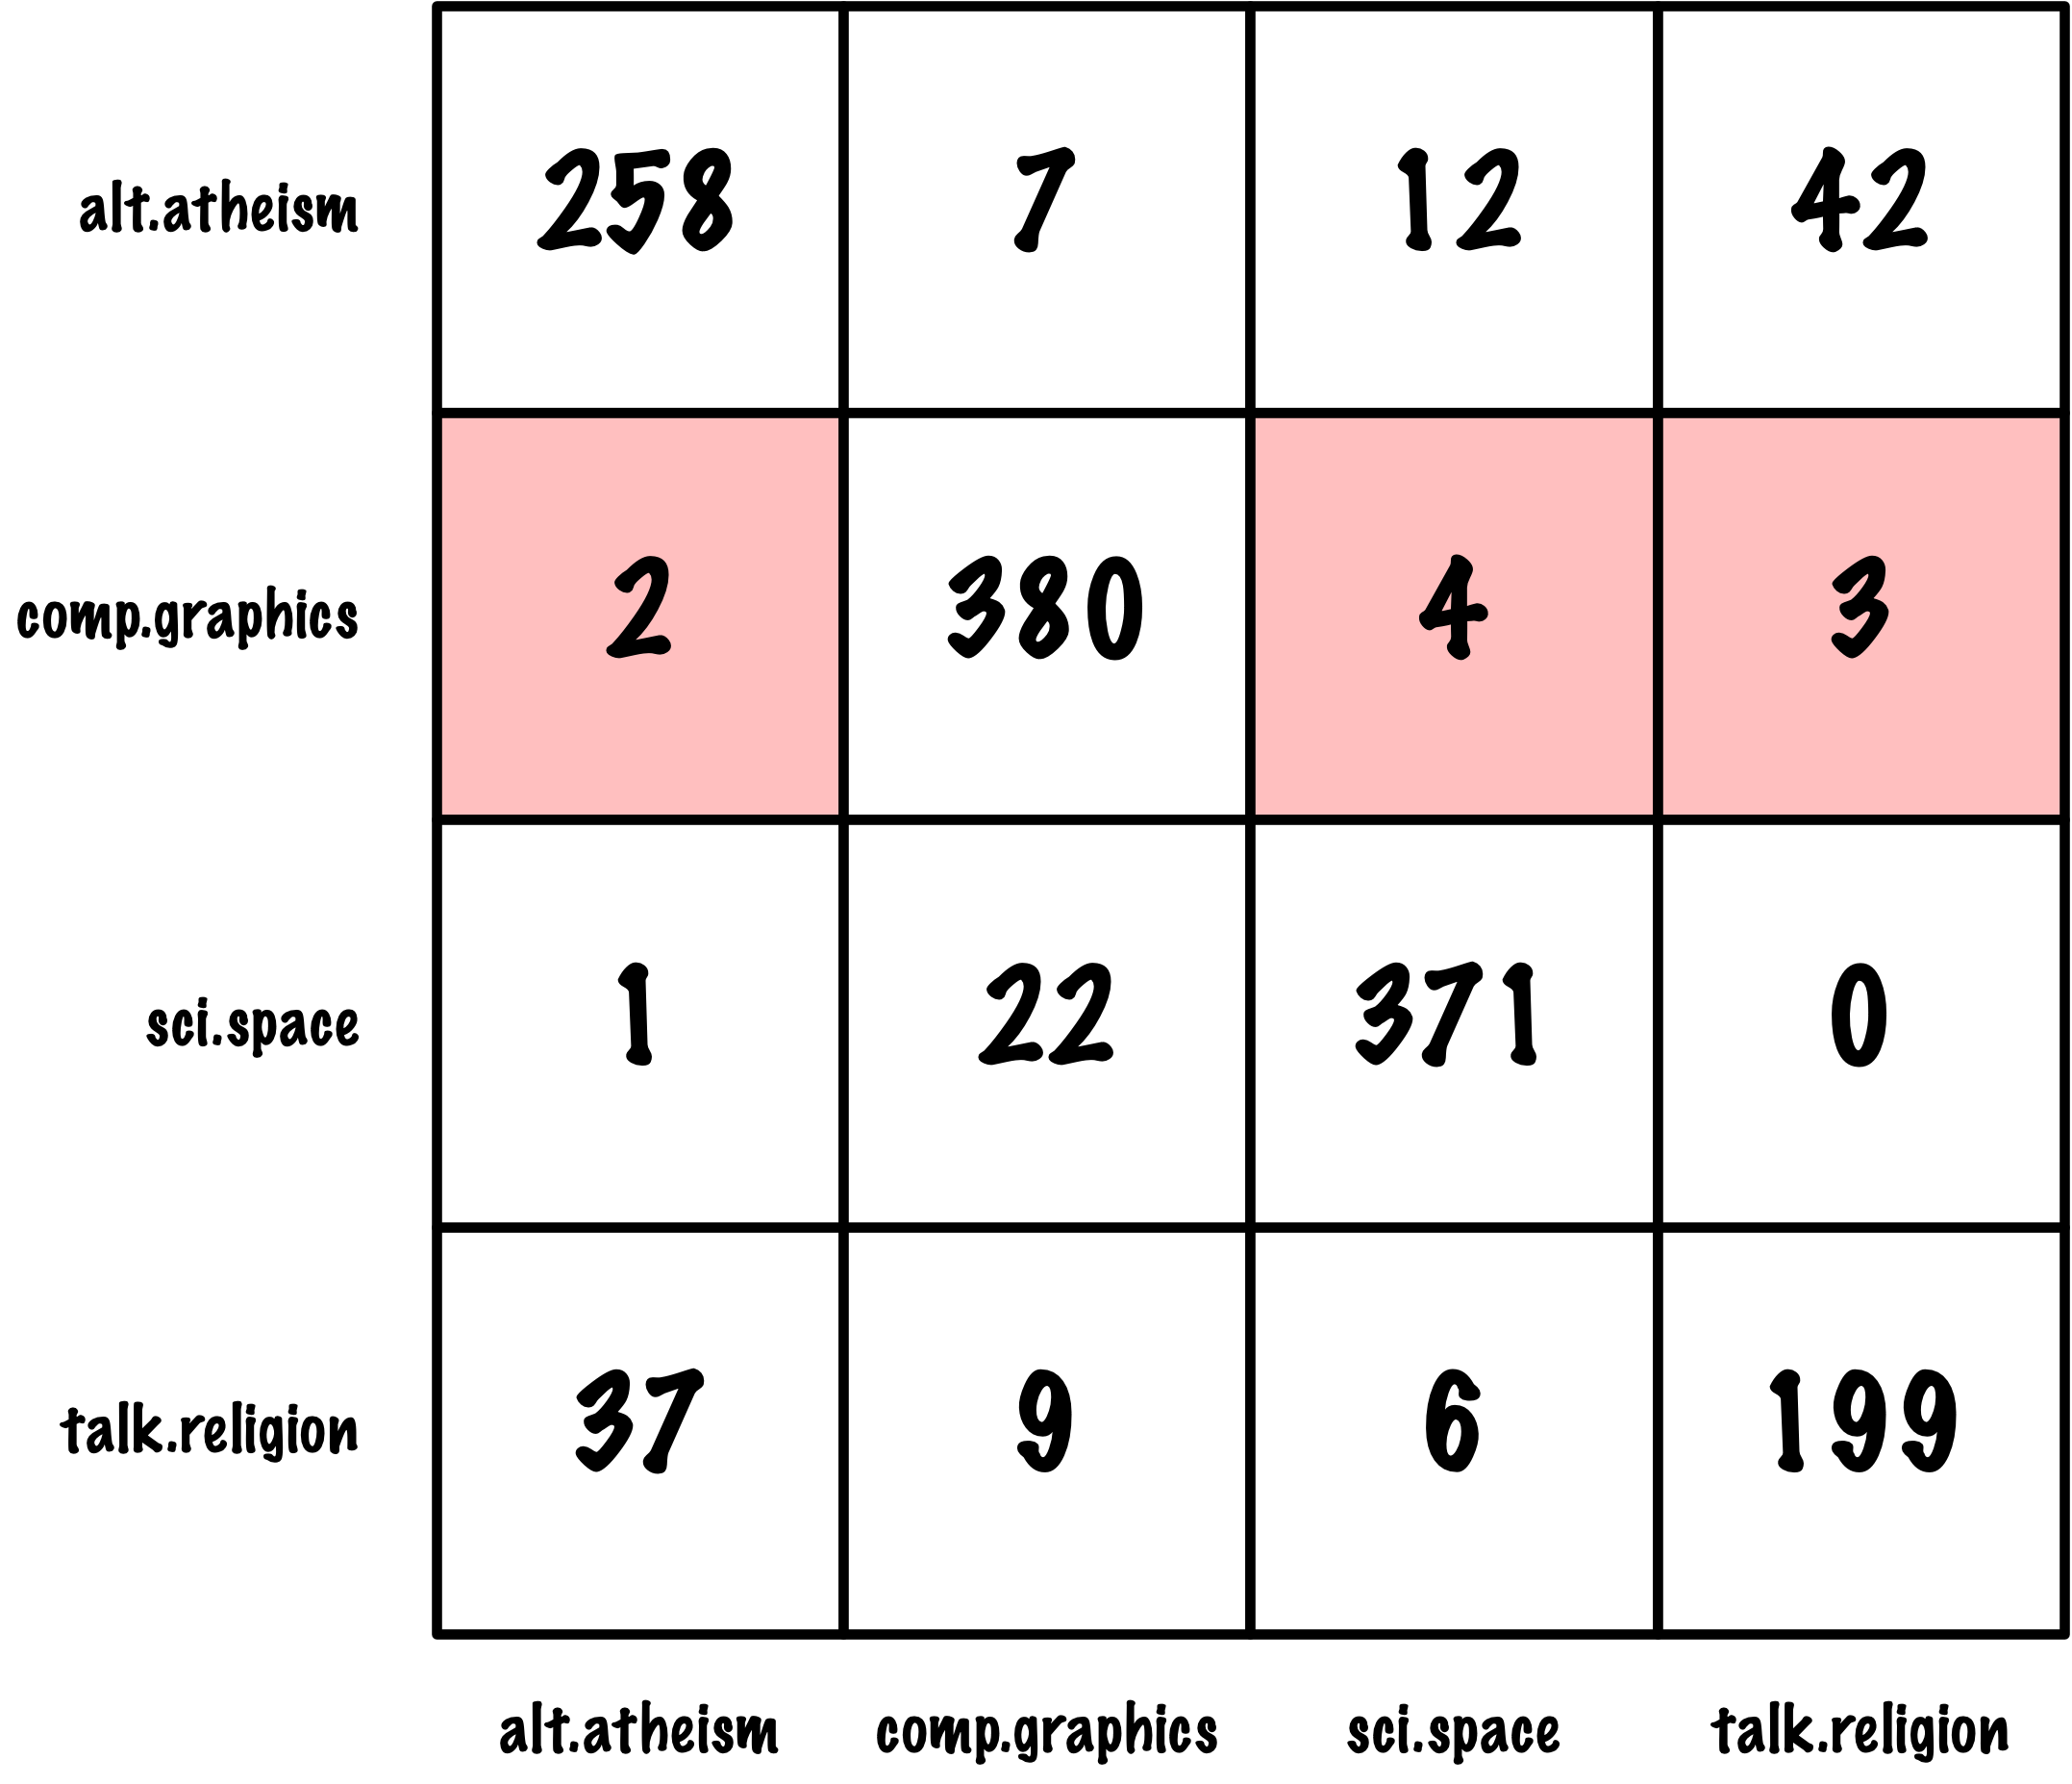

The example belongs to `comp.graphics`, but the model predicts another
class.

## Confusion Matrix: True Negative

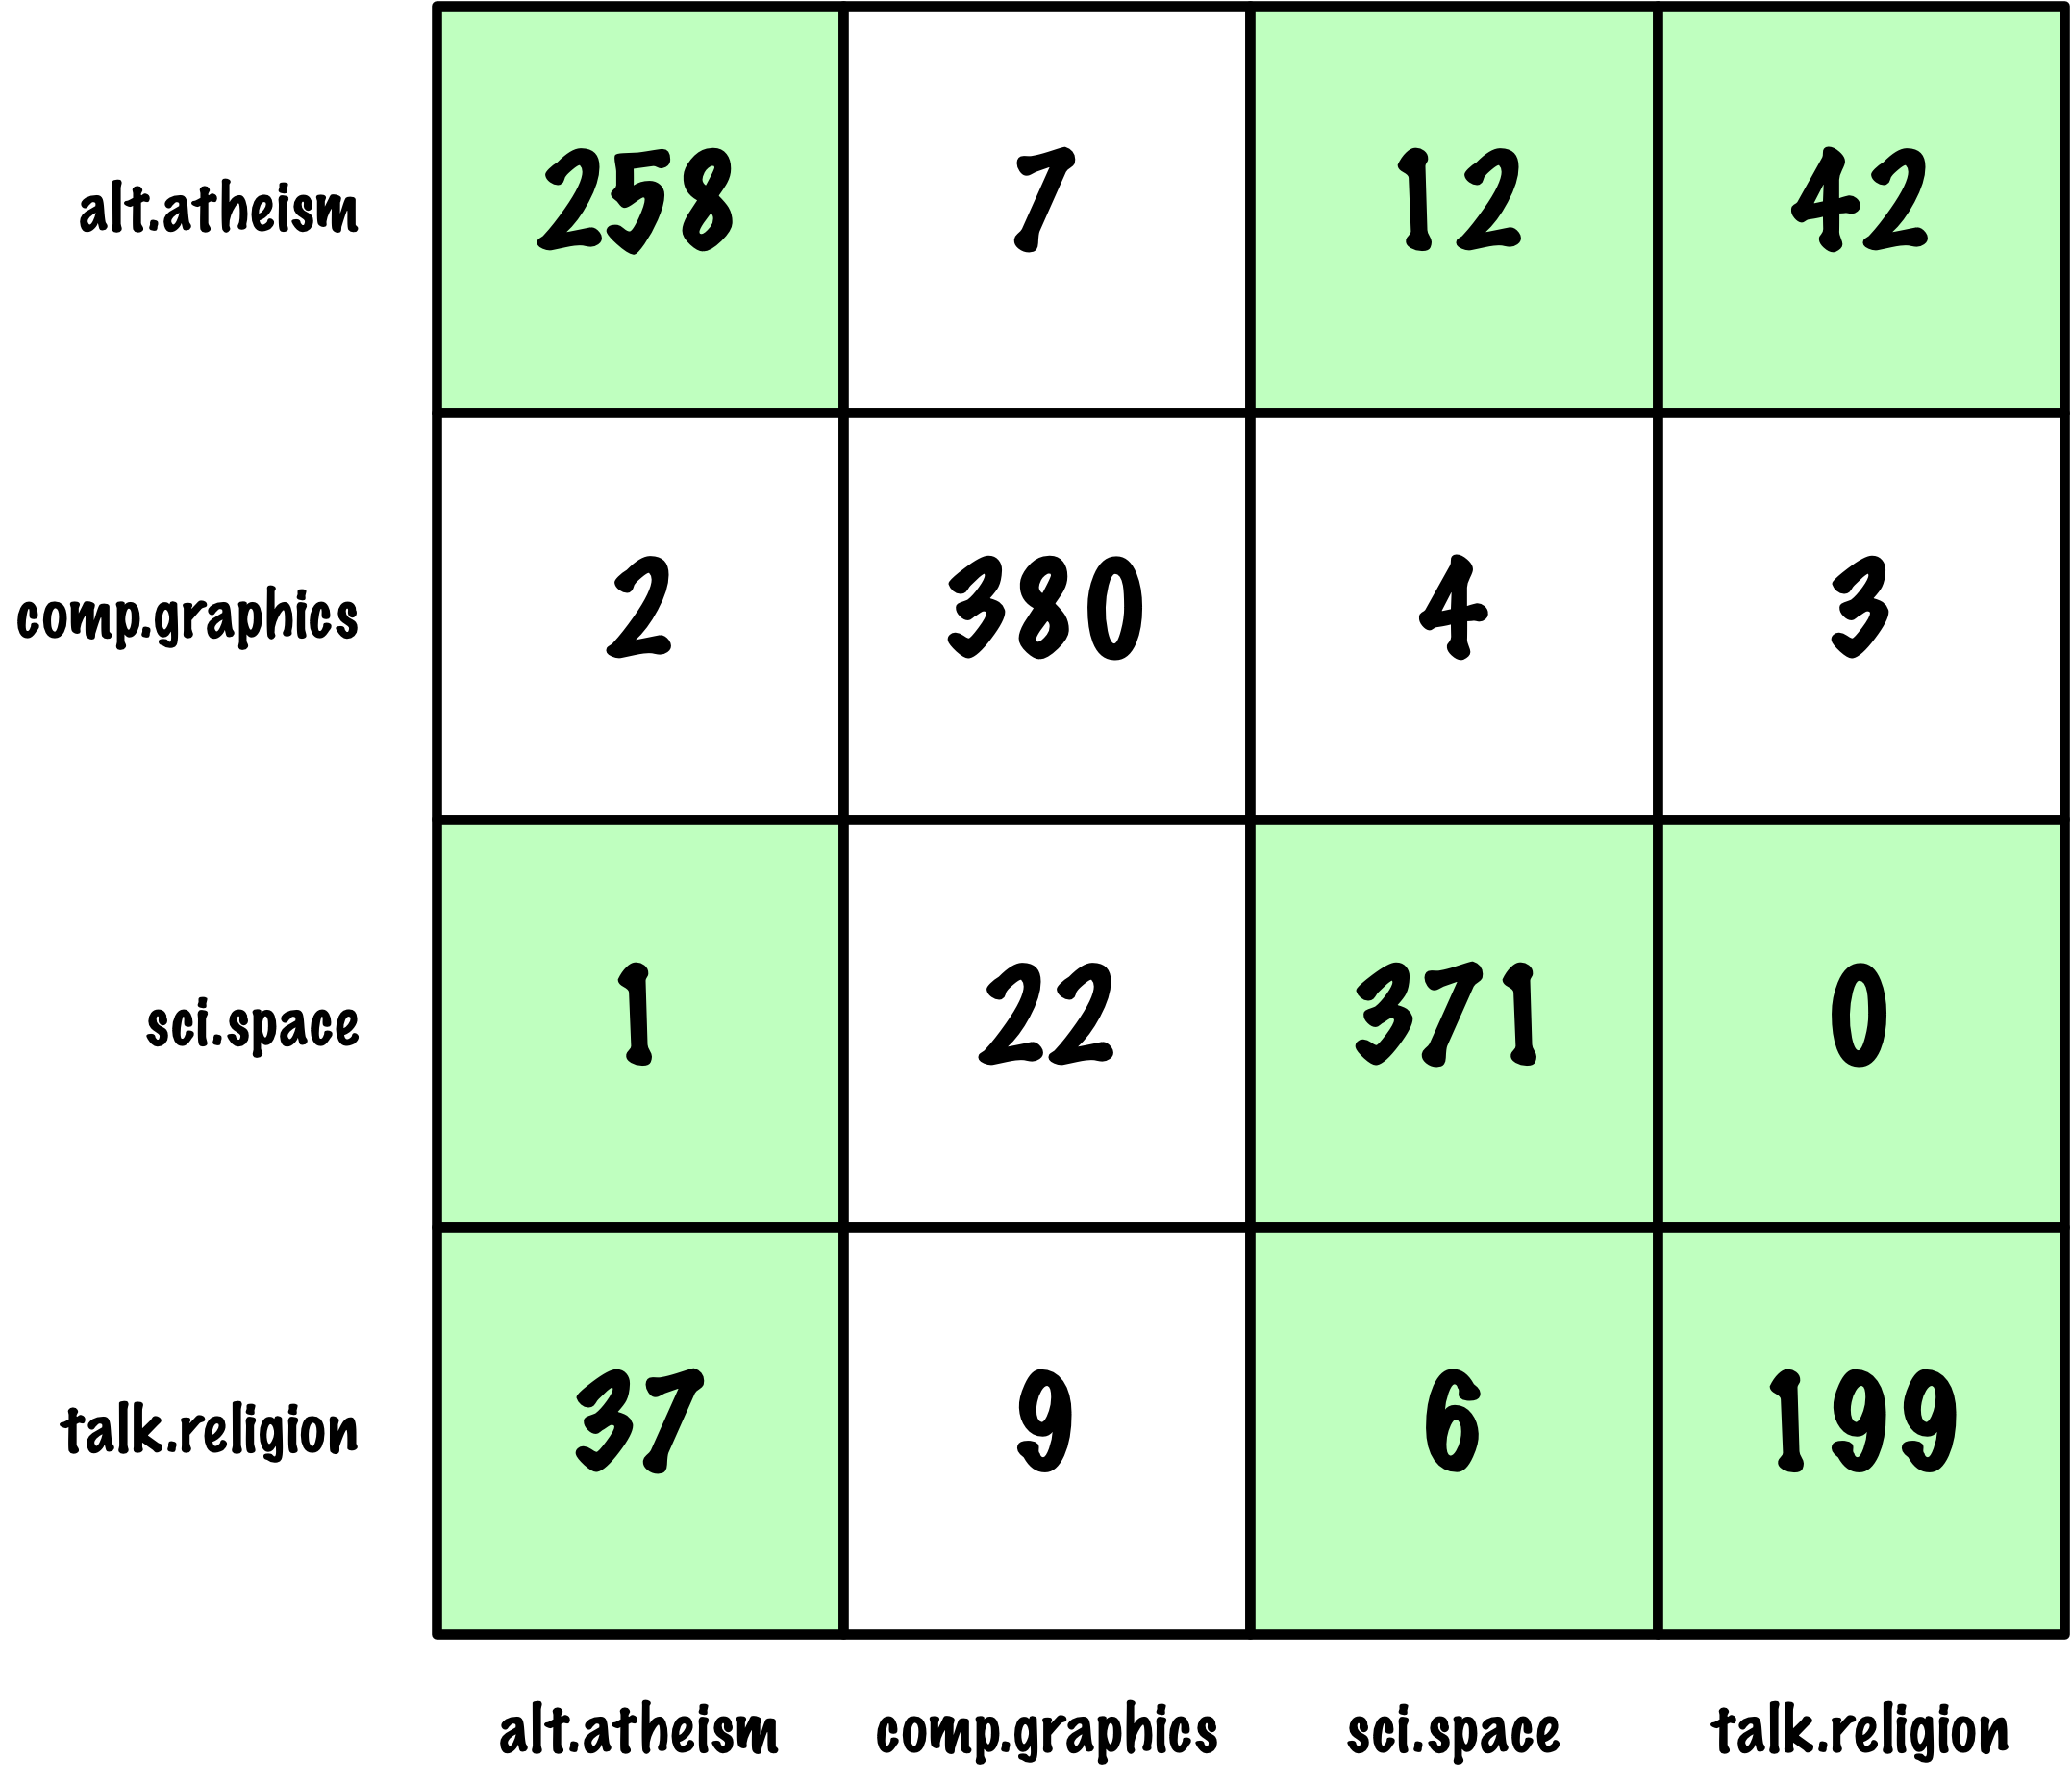

Neither the actual class nor the predicted class is `comp.graphics`.

## Confusion Matrix: Multiclass

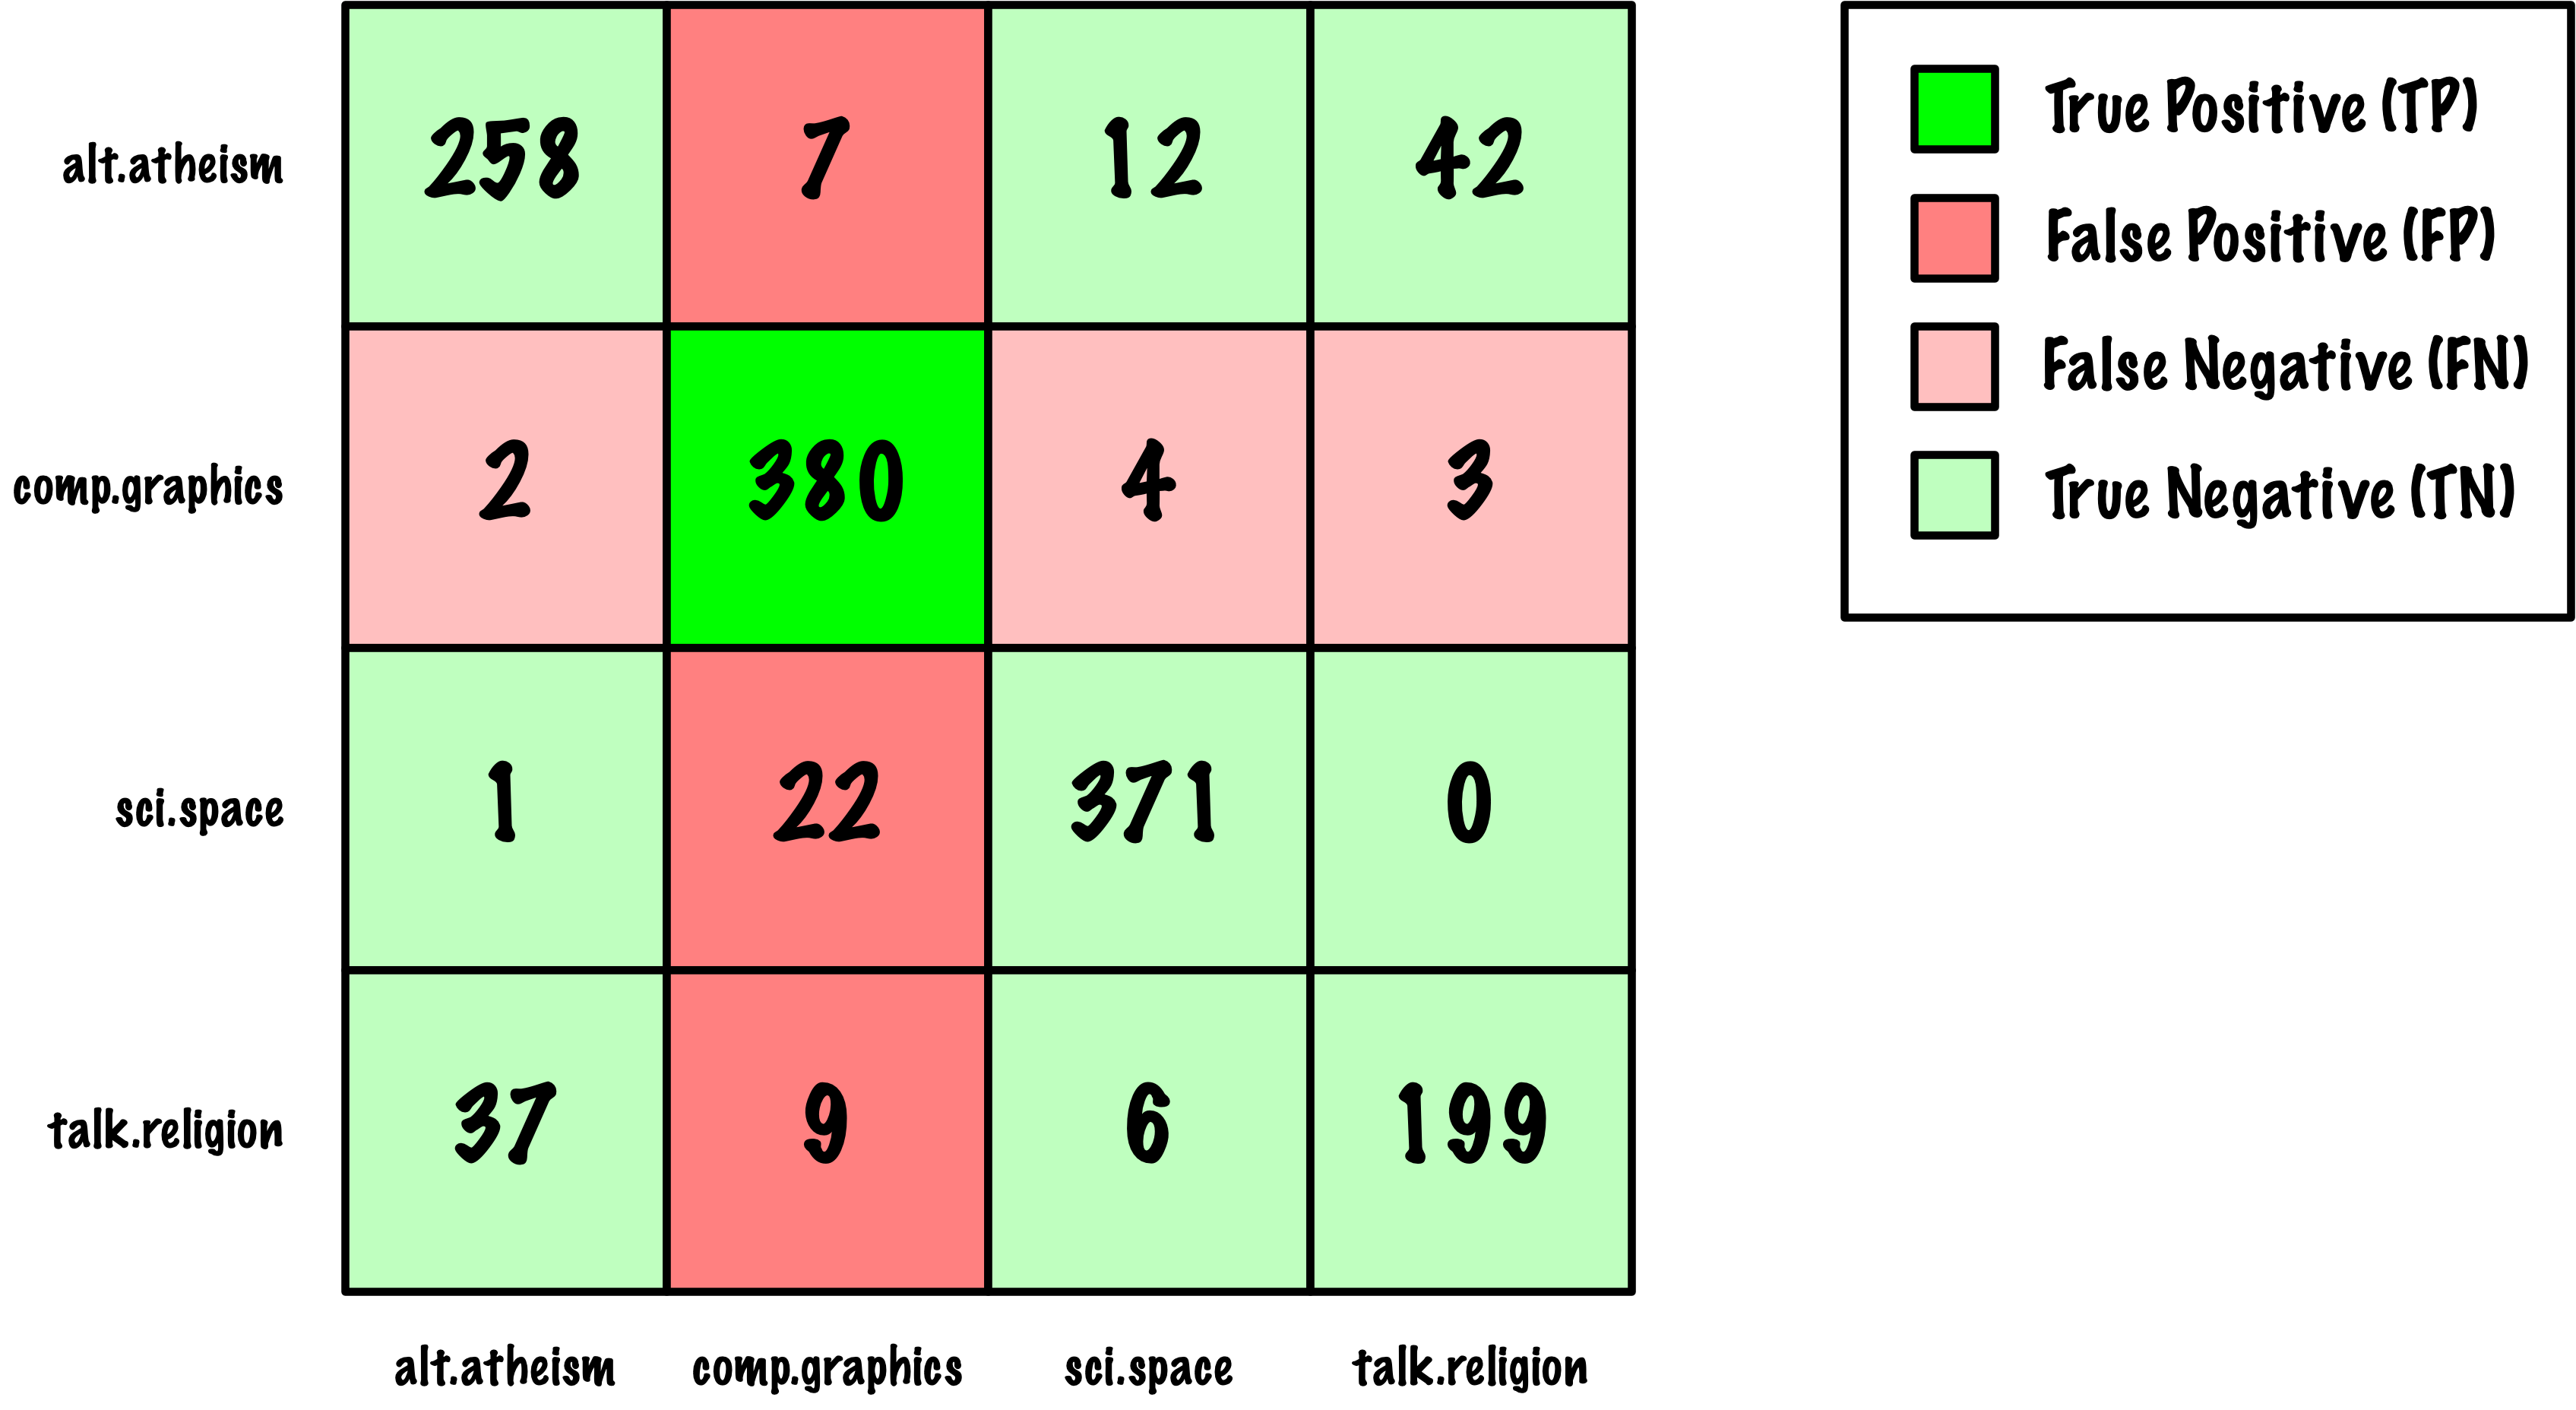

Together, these four regions form the one-vs-rest confusion matrix for
`comp.graphics`.

## Multiclass counts

For class $i$, treat that class as positive and all other classes as
negative:

- **True Positives** ($\mathrm{TP}_i$): Diagonal entry $C_{i,i}$
- **False Positives** ($\mathrm{FP}_i$): Sum of column $i$ excluding
  $C_{i,i}$
- **False Negatives** ($\mathrm{FN}_i$): Sum of row $i$ excluding
  $C_{i,i}$
- **True Negatives** ($\mathrm{TN}_i$):
  $N - (\mathrm{TP}_i + \mathrm{FP}_i + \mathrm{FN}_i)$, equivalently
  $\sum_{j \ne i}\sum_{k \ne i}C_{j,k}$

## sklearn.metrics.confusion_matrix

In [2]:
from sklearn.metrics import confusion_matrix

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

confusion_matrix(y_actual,y_pred)

array([[1, 2],
       [3, 4]])

. . .

In [3]:
tn, fp, fn, tp = confusion_matrix(y_actual, y_pred).ravel().tolist()
(tn, fp, fn, tp)

(1, 2, 3, 4)

By default, `sklearn.metrics.confusion_matrix` determines the set of
labels from the data ($\textrm{y_true} \cup \textrm{y_pred}$), and then:

- It sorts labels in ascending order. String labels use lexicographic
  ordering. Mixed string and numeric labels are not supported.
- It then builds the matrix so that row `i` corresponds to the true
  class with label `labels[i]`, and column `j` corresponds to the
  predicted class with label `labels[j]`.

If you do not pass `labels=...`, the class order may differ from what
you expect. This is especially relevant for string labels or when you
assume the matrix follows the order of appearance in the dataset.

**Example**

``` python
from sklearn.metrics import confusion_matrix

y_true = ["dog", "cat", "cat", "dog"]
y_pred = ["dog", "dog", "cat", "cat"]

print(confusion_matrix(y_true, y_pred))
```

Output:

    [[1 1]
     [1 1]]

Here the rows/columns are in lexicographic order: `["cat", "dog"]`. So
the matrix is:

- Row 0: true = “cat”
- Row 1: true = “dog”

**Controlling order**

To force a specific order, you should pass the labels argument:

``` python
confusion_matrix(y_true, y_pred, labels=["dog", "cat"])
```

This will swap the row/column order accordingly.

## Perfect Prediction

In [4]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]

confusion_matrix(y_actual,y_pred)

array([[4, 0],
       [0, 6]])

. . .

In [5]:
tn, fp, fn, tp = confusion_matrix(y_actual, y_pred).ravel().tolist()  
(tn, fp, fn, tp)

(4, 0, 0, 6)

When an algorithm achieves perfect classification accuracy, all non-zero
values in the confusion matrix appear exclusively along its diagonal.

All off-diagonal entries, which represent misclassifications, will be
zero.

## Confusion Matrix: Multiple Classes

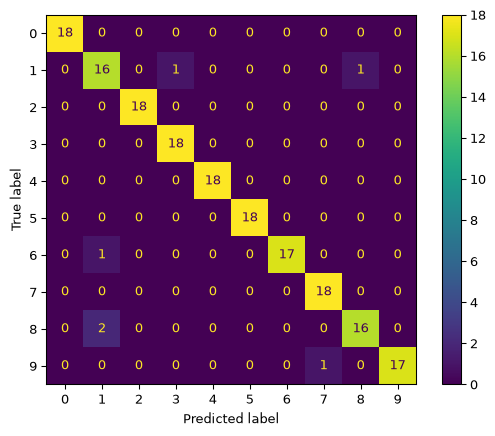

In [6]:
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=seed,
    stratify=y,
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

**Confusion matrix** for the **digits example** presented in the
previous lecture.

The image displays a heatmap of the confusion matrix for the digit
classification task. This task, a multiclass classification problem, was
addressed using `OneVsRestClassifier` and `LogisticRegression`.

The confusion matrix summarizes the predictions made on the test set,
which is a subset of the data that was neither used for training nor for
preprocessing with `StandardScaler`.

The confusion matrix contains the prediction results for the test set.
Performance metrics summarize these counts in a smaller number of
values.

## Visualizing errors

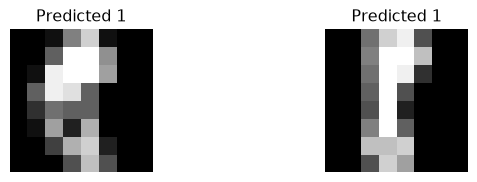

In [7]:
mask = (y_test == 8) & (y_pred == 1)
misclassified_images = X_test[mask][:5]

plt.figure(figsize=(8, 2))
for index, image in enumerate(misclassified_images):
    plt.subplot(1, len(misclassified_images), index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
    plt.title("Predicted 1")
    plt.axis("off")

plt.tight_layout()
plt.show()

The preceding confusion matrix shows examples whose true label is 8 but
whose predicted label is 1. Inspecting the original pixel values, rather
than the standardized features supplied to the classifier, preserves the
appearance of each digit.

## Accuracy

How **accurate** is this result?

$$
  \mathrm{accuracy} = \frac{\mathrm{TP}+\mathrm{TN}}{\mathrm{TP}+\mathrm{TN}+\mathrm{FP}+\mathrm{FN}} = \frac{\mathrm{TP}+\mathrm{TN}}{\mathrm{N}}
$$

In [8]:
from sklearn.metrics import accuracy_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

accuracy_score(y_actual,y_pred)

0.5

**Accuracy** is the ratio of correctly predicted instances to the total
number of predictions.

## Accuracy

In [9]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [1, 0, 1, 1, 0, 0, 0, 1, 0, 0]

accuracy_score(y_actual,y_pred)

0.0

In [10]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]

accuracy_score(y_actual,y_pred)

1.0

**Accuracy** is a number between 0 (all wrong) and 1 (perfect).

## Accuracy can be misleading

In [11]:
y_actual = [0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
y_pred   = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

accuracy_score(y_actual,y_pred)

0.8

**Why** is it problematic?

**Class imbalance** occurs when one class contains substantially more
examples than another. Accuracy can then disproportionately reflect
performance on the majority class and mask poor performance on the
minority class.

As class imbalance increases, accuracy can become increasingly
misleading. We return to this issue later in the lecture when we
introduce micro and macro averaging.

## Precision

Also known as **positive predictive value** (PPV).

$$
  \mathrm{precision} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FP}}
$$

In [12]:
from sklearn.metrics import precision_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

precision_score(y_actual, y_pred)

0.6666666666666666

**Precision** is the proportion of **true positive predictions** among
**all positive predictions**.

Can you think of a problem or situation where precision is especially
important?

One example is selecting candidate compounds for expensive laboratory
validation.

- A model screens a large compound library and predicts which compounds
  are active.
- Each positive prediction triggers a costly experiment.
- High precision means that a larger proportion of the tested compounds
  are genuinely active:

$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

- Higher precision reduces the number of experiments spent on inactive
  compounds.

Other real-world settings where precision is key:

- Spam detection: High precision ensures that emails classified as spam
  are really spam (minimizing false positives that would hide real
  emails).
- Legal document search / e-discovery: High precision ensures that
  returned documents are relevant, reducing time wasted on irrelevant
  results.
- Recommender systems: High precision means that recommended items are
  very likely to be of interest, improving user trust.

## Precision alone is not enough

In [13]:
y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

precision_score(y_actual,y_pred)

1.0

An algorithm that makes a small number of high-confidence predictions
might achieve a high precision score, but this may not necessarily be
useful.

## Recall

Also known as **sensitivity** or **true positive rate** (TPR). $$
  \mathrm{recall} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}}
$$

In [14]:
from sklearn.metrics import recall_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

recall_score(y_actual,y_pred)

0.5714285714285714

**Recall** is the proportion of true positive instances correctly
identified among all actual positive instances.

Can you think of a problem or situation where recall is especially
important?

One example is **cancer screening for malignant tumours**.

- Here, false negatives (missing an actual cancer case) are far more
  dangerous than false positives.
- Recall measures the proportion of actual positives correctly
  identified:

$$
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

- A high recall means the test finds nearly all patients with cancer,
  even if it also produces some false alarms.
- Missing a true case could delay treatment. In this setting, that error
  is more serious than investigating additional false positives.

Other real-world settings where recall matters most:

- Security / Intrusion detection: Better to flag all suspicious activity
  (even with false positives) than miss a real attack.
- Search engines: For certain queries (e.g., legal precedent search,
  medical literature search), recall ensures you retrieve all relevant
  documents.
- Emergency response systems: For natural disaster warnings, high recall
  ensures no real threat goes unnoticed.

## F$_1$ score

$$
\begin{align*}
  F_1~\mathrm{score} &= \frac{2}{\frac{1}{\mathrm{precision}}+\frac{1}{\mathrm{recall}}} = 2 \times \frac{\mathrm{precision}\times\mathrm{recall}}{\mathrm{precision}+\mathrm{recall}} \\
                     &= \frac{\mathrm{TP}}{\mathrm{TP}+\frac{\mathrm{FN}+\mathrm{FP}}{2}}
\end{align*}
$$

In [15]:
from sklearn.metrics import f1_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

f1_score(y_actual,y_pred)

0.6153846153846154

**F$_1$** is the **harmonic mean** of precision and recall.

- The harmonic mean is pulled towards the lower of precision and recall,
  so a high $F_1$ score requires both to be high.
- The $F_1$ score gives precision and recall equal importance.
  Applications with unequal error costs may require a different metric
  or an explicit threshold choice.
- Increasing **recall** often decreases **precision**, and vice versa.
  This relationship is the **precision-recall trade-off**.

# Micro and Macro Averaging

## Definition

The **class imbalance problem** occurs when one class has substantially
more examples than another.

. . .

Without appropriate training and evaluation choices, a model may favour
the **majority class** and perform poorly on the **minority class**.

Standard evaluation metrics like accuracy may be misleading in the
presence of class imbalance.

The next two slides introduce micro and macro averaging. The distinction
can seem abstract at first. The worked confusion-matrix examples that
follow show exactly which counts each method combines and why the two
averages can differ.

## Micro Performance Metrics

- Micro averaging **pools the true positives, false positives, and false
  negatives across classes** before computing precision, recall, or
  $F_1$.
- It **treats each prediction equally**, so frequent classes contribute
  more to the final metric.

## Macro Performance Metrics

- Macro averaging **computes the metric independently for each class and
  then takes the arithmetic mean**.
- It **treats each class equally**, regardless of its frequency, so poor
  performance on an infrequent class remains visible.

A useful mnemonic is the level of aggregation:

- **Micro** works at the finer level of individual predictions. It pools
  the contributions from every example before computing the metric.
- **Macro** works at the class level. It computes one metric for each
  class, where each class contains many examples, and then averages
  those class-level values.

## Multiclass metrics

When calculating **precision**, **recall**, and $F_1$, one usually
computes one-vs-rest metrics for each class and then averages them using
a **micro** or **macro** scheme.

- **True Positives** ($\mathrm{TP}_i$): Diagonal entry $C_{i,i}$
- **False Positives** ($\mathrm{FP}_i$): Sum of column $i$ excluding
  $C_{i,i}$
- **False Negatives** ($\mathrm{FN}_i$): Sum of row $i$ excluding
  $C_{i,i}$
- **True Negatives** ($\mathrm{TN}_i$):
  $N - (\mathrm{TP}_i + \mathrm{FP}_i + \mathrm{FN}_i)$

## Multiclass formulas

When calculating **precision**, **recall**, and $F_1$, one usually
computes one-vs-rest metrics for each class and then averages them using
a micro or macro scheme.

- $\mathrm{TP}_i = C_{i,i}$
- $\mathrm{FP}_i = \sum_{k \ne i} C_{k,i}$
- $\mathrm{FN}_i = \sum_{k \ne i} C_{i,k}$
- $\mathrm{TN}_i = \sum_{j \ne i} \sum_{k \ne i} C_{j,k}$

## Micro/Macro Metrics

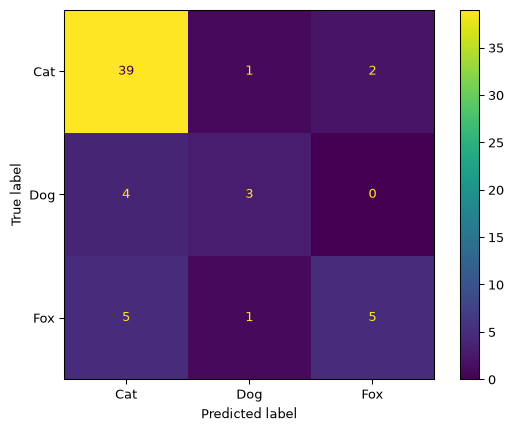

In [16]:
# Sample data
y_true = ['Cat'] * 42 + ['Dog'] *  7 + ['Fox'] * 11
y_pred = ['Cat'] * 39 + ['Dog'] *  1 + ['Fox'] *  2 + \
         ['Cat'] *  4 + ['Dog'] *  3 + ['Fox'] *  0 + \
         ['Cat'] *  5 + ['Dog'] *  1 + ['Fox'] *  5

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

The dataset can be conceptualized as resulting from an **image
classification task**, involving images of **cats**, **dogs**, and
**foxes**. Reflecting common trends observed on the internet, images of
cats are disproportionately represented, leading to a **class
imbalance** issue.

## Micro/Macro Precision

In [17]:
from sklearn.metrics import classification_report, precision_score

print(classification_report(y_true, y_pred), "\n")

micro_precision = precision_score(y_true, y_pred, average="micro")
macro_precision = precision_score(y_true, y_pred, average="macro")
print(f"Micro precision: {micro_precision:.2f}")
print(f"Macro precision: {macro_precision:.2f}")

              precision    recall  f1-score   support

         Cat       0.81      0.93      0.87        42
         Dog       0.60      0.43      0.50         7
         Fox       0.71      0.45      0.56        11

    accuracy                           0.78        60
   macro avg       0.71      0.60      0.64        60
weighted avg       0.77      0.78      0.77        60
 

Micro precision: 0.78
Macro precision: 0.71

## Micro/Macro Precision

- **Macro-average precision** is calculated as the mean of the
  **precision** scores[1] for each class:
  $\frac{0.81 + 0.60 + 0.71}{3} = 0.71$.

- **Micro-average precision** pools the counts from the entire confusion
  matrix:
  $\frac{TP}{TP+FP} = \frac{39+3+5}{39+3+5+9+2+2} = \frac{47}{60} = 0.78$.

The high micro-average precision observed here is primarily due to the
high precision and large number of examples in the majority class, Cat.
This masks the classifier’s relatively poor performance on the minority
classes, Dog and Fox.

Micro and macro averages are similar when class frequencies and
class-specific performance are similar. Class balance alone does not
guarantee that the two averages will agree.

With imbalanced classes, poor performance on a minority class may have
little effect on the micro average but a substantial effect on the macro
average.

In **macro-average metrics**, each class contributes equally to the
final metric calculation, **irrespective of the number of examples it
contains**. The metric is computed independently for each class and then
averaged, without weighting classes by their frequency. Consequently,
macro-averaging ensures that **each class has an equal impact on the
overall metric**, which can be particularly useful when the class
distribution is imbalanced.

## Micro/Macro Recall

[1] The averaging step gives every class equal weight rather than
weighting class-specific precision by class frequency.

In [18]:
from sklearn.metrics import classification_report, recall_score

print(classification_report(y_true, y_pred), "\n")

micro_recall = recall_score(y_true, y_pred, average="micro")
macro_recall = recall_score(y_true, y_pred, average="macro")
print(f"Micro recall: {micro_recall:.2f}")
print(f"Macro recall: {macro_recall:.2f}")

              precision    recall  f1-score   support

         Cat       0.81      0.93      0.87        42
         Dog       0.60      0.43      0.50         7
         Fox       0.71      0.45      0.56        11

    accuracy                           0.78        60
   macro avg       0.71      0.60      0.64        60
weighted avg       0.77      0.78      0.77        60
 

Micro recall: 0.78
Macro recall: 0.60

## Micro/Macro Recall

- **Macro-average** recall is calculated as the **mean of the recall
  scores for each class**: $\frac{0.93 + 0.43 + 0.45}{3} = 0.60$.

- **Micro-average recall** pools the counts from the entire confusion
  matrix:
  $\frac{TP}{TP+FN} = \frac{39+3+5}{39+3+5+3+4+6} = \frac{47}{60} = 0.78$.

Micro averages in single-label multiclass classification

Each example contributes one actual label and one predicted label.
Therefore,

$$
\text{micro precision}
= \text{micro recall}
= \text{micro }F_1
= \text{accuracy}.
$$

For this example, every micro-averaged metric equals $47/60 = 0.78$.
Macro averages can differ because they give every class equal weight.

# Class Imbalance in Medical Data

## Micro/Macro Metrics (Medical Data)

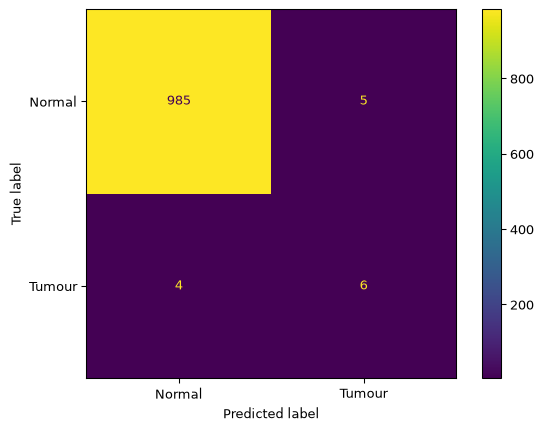

In [19]:
# Sample data
y_true = ['Normal'] *  990 + ['Tumour'] *  10
y_pred = ['Normal'] *  985 + ['Tumour'] *   5 + \
         ['Normal'] *    4 + ['Tumour'] *   6

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

Consider a medical dataset, such as one involving diagnostic tests or
imaging, comprising 990 normal samples and 10 abnormal (tumour) samples.
This represents the ground truth.

## Micro/macro metrics (medical data)

In [20]:
from sklearn.metrics import classification_report, recall_score

print(classification_report(y_true, y_pred), "\n")

micro_precision = precision_score(y_true, y_pred, average="micro")
macro_precision = precision_score(y_true, y_pred, average="macro")
print(f"Micro precision: {micro_precision:.2f}")
print(f"Macro precision: {macro_precision:.2f}")

print("\n")

micro_recall = recall_score(y_true, y_pred, average="micro")
macro_recall = recall_score(y_true, y_pred, average="macro")
print(f"Micro recall: {micro_recall:.2f}")
print(f"Macro recall: {macro_recall:.2f}")

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       990
      Tumour       0.55      0.60      0.57        10

    accuracy                           0.99      1000
   macro avg       0.77      0.80      0.78      1000
weighted avg       0.99      0.99      0.99      1000
 

Micro precision: 0.99
Macro precision: 0.77


Micro recall: 0.99
Macro recall: 0.80

The precision for the `Tumour` class is low. However, due to the small
sample size, this does not significantly impact the micro-averaged
precision.

# Precision-Recall Trade-Off

## Handwritten Digits (Revisited)

Loading the dataset

In [21]:
from sklearn.datasets import fetch_openml

digits = fetch_openml('mnist_784', as_frame=False)
X, y = digits.data, digits.target

Plotting the first five examples

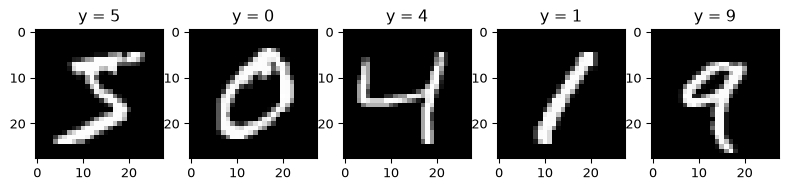

In [22]:
plt.figure(figsize=(10,2))
n = 5

for index, (image, label) in enumerate(zip(X[0:n], y[0:n])):
    plt.subplot(1, n, index + 1)
    plt.imshow(np.reshape(image, (28,28)), cmap=plt.cm.gray)
    plt.title(f'y = {label}')

These images have dimensions of $28 \times 28$ pixels.

## Creating a Binary Classification Task

In [23]:
# Creating a binary classification task (one vs the rest)

some_digit = X[0]
some_digit_y = y[0]

y = (y == some_digit_y)
y

array([ True, False, False, ..., False,  True, False], shape=(70000,))

. . .

In [24]:
# Creating the training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=seed,
    stratify=y,
)

## `SGDClassifier`

In [25]:
from sklearn.linear_model import SGDClassifier

clf = SGDClassifier(random_state=seed)

clf.fit(X_train, y_train)

`SGDClassifier` is a linear classifier trained with stochastic gradient
descent. It is well suited to this large dataset and exposes a
continuous score through `decision_function`. Logistic regression also
exposes probabilities and decision scores that can be thresholded.

## Performance

In [26]:
y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.9657142857142857

. . .

The score appears strong,

. . .

but the class distribution provides essential context.

## Not so Fast

In [27]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")

dummy_clf.fit(X_train, y_train)

. . .

In [28]:
y_pred = dummy_clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.9098571428571428

The <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html"
class="external" data-icon="true">DummyClassifier</a> in scikit-learn
generates predictions without considering the input features. With
`strategy="most_frequent"`, it consistently predicts the most frequent
class label in the training data and provides a simple baseline.

Why is the accuracy so high despite this classifier ignoring the input
data?

The high accuracy is attributed to the class distribution within the
dataset. Approximately 10% of the samples correspond to the digit ‘5’,
which is the positive class in our binary classification task.
Consequently, about 90% of the samples are ‘not 5’ and belong to the
negative class. Since the DummyClassifier always predicts the majority
class, its accuracy is expected to be around 90%.

This illustrates why accuracy alone is insufficient for evaluating an
imbalanced dataset.

## Precision-Recall Trade-Off

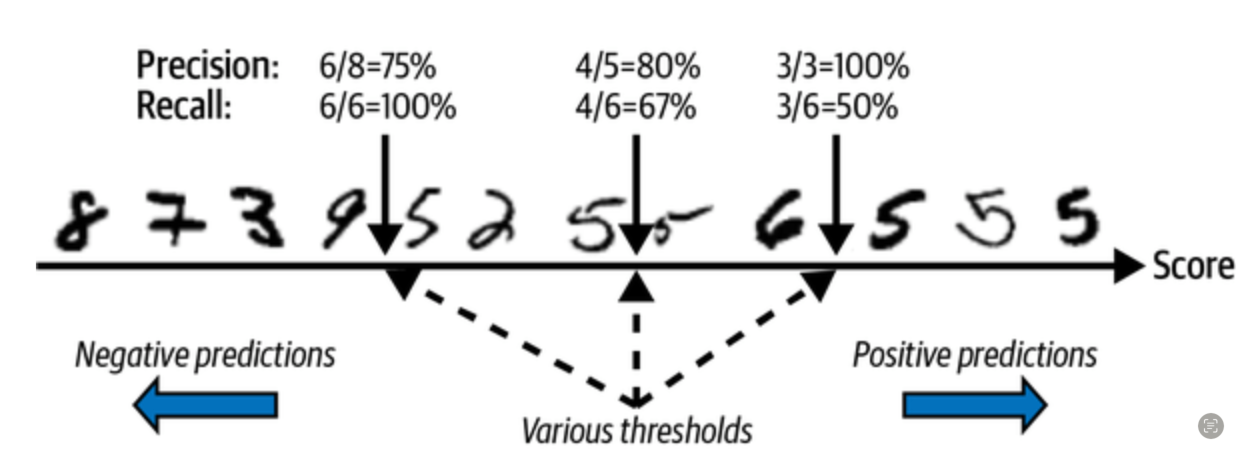

**Attribution**: Géron (2022) Figure 3.4

## Precision-Recall Trade-Off

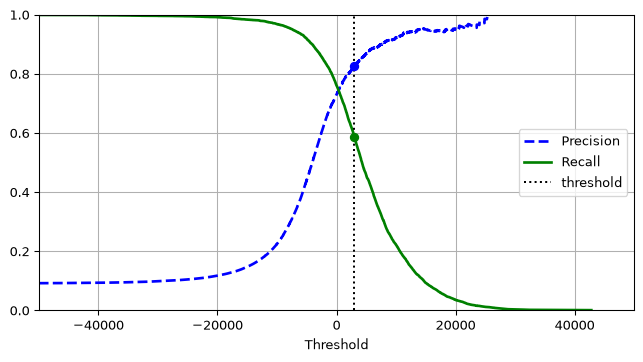

In [29]:
from sklearn.model_selection import cross_val_predict
y_scores = cross_val_predict(
    clf,
    X_train,
    y_train,
    cv=3,
    method="decision_function",
)

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train,
    y_scores,
)

threshold = 3000

plt.figure(figsize=(8, 4))
plt.plot(
    thresholds,
    precisions[:-1],
    "b--",
    label="Precision",
    linewidth=2,
)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

The continuous score produced by `decision_function` lets us vary the
decision threshold and observe the precision-recall trade-off. (Géron
2022) <a
href="https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb"
class="external"
data-icon="true"><code>03_classification.ipynb</code></a>.

As the decision threshold decreases, a higher number of examples are
predicted as positive, potentially leading the classifier to eventually
label all instances as positive.

Conversely, as the decision threshold increases, fewer examples are
classified as positive, which may result in the classifier predicting no
positive instances at all.

For certain applications, a classifier with high precision is essential.
For example, consider a scenario where each prediction necessitates a
costly laboratory experiment to verify its accuracy, such as in a
pharmaceutical company aiming to discover new drugs. Here, the
classifier predicts whether a compound is active. Given the high cost of
experiments to validate candidates, the company would prioritize
focusing on the most promising compounds first.

In contrast, consider a scenario involving cancer screening, such as
using mammograms to detect breast cancer. In this case, it may be
preferable to lower the decision threshold, thereby increasing the
number of false-positive predictions. Although this approach results in
more patients undergoing additional tests, such as biopsies, it can
potentially save more lives by ensuring that fewer cases of cancer go
undetected.

## Precision/Recall Curve

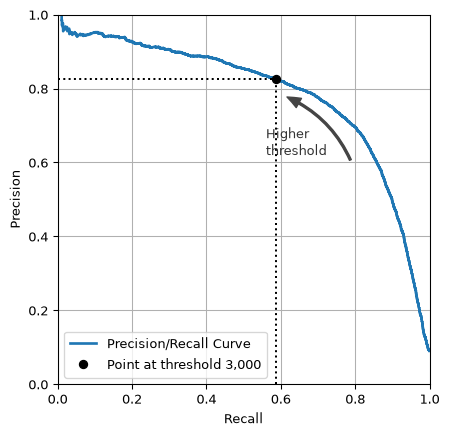

In [30]:
import matplotlib.patches as patches

plt.figure(figsize=(5, 5))

plt.plot(
    recalls,
    precisions,
    linewidth=2,
    label="Precision/Recall Curve",
)

plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

(Géron 2022) <a
href="https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb"
class="external"
data-icon="true"><code>03_classification.ipynb</code></a>.

# ROC Curve

## ROC Curve

**Receiver operating characteristic (ROC) curve**

- **True positive rate** (TPR) against **false positive rate** (FPR)
- An ideal classifier has **TPR** close to **1.0** and **FPR** close to
  **0.0**
- $\mathrm{TPR} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}}$ (recall,
  sensitivity)
- **TPR** approaches **one** when there are few **false negatives**
- $\mathrm{FPR} = \frac{\mathrm{FP}}{\mathrm{FP}+\mathrm{TN}} = 1-\mathrm{specificity}$
- **FPR** approaches **zero** when the number of **false positives** is
  low

An ROC curve plots the true-positive rate against the false-positive
rate as the decision threshold varies. Each threshold produces one
operating point. An ideal operating point lies near the upper-left
corner, while random ranking produces the diagonal on average.

The curve summarizes score ranking across thresholds, but a deployment
decision still requires a particular threshold. The relative costs of
false positives and false negatives help determine which operating point
is appropriate. One-vs-rest evaluation extends ROC analysis to
multiclass tasks.

## ROC Curve

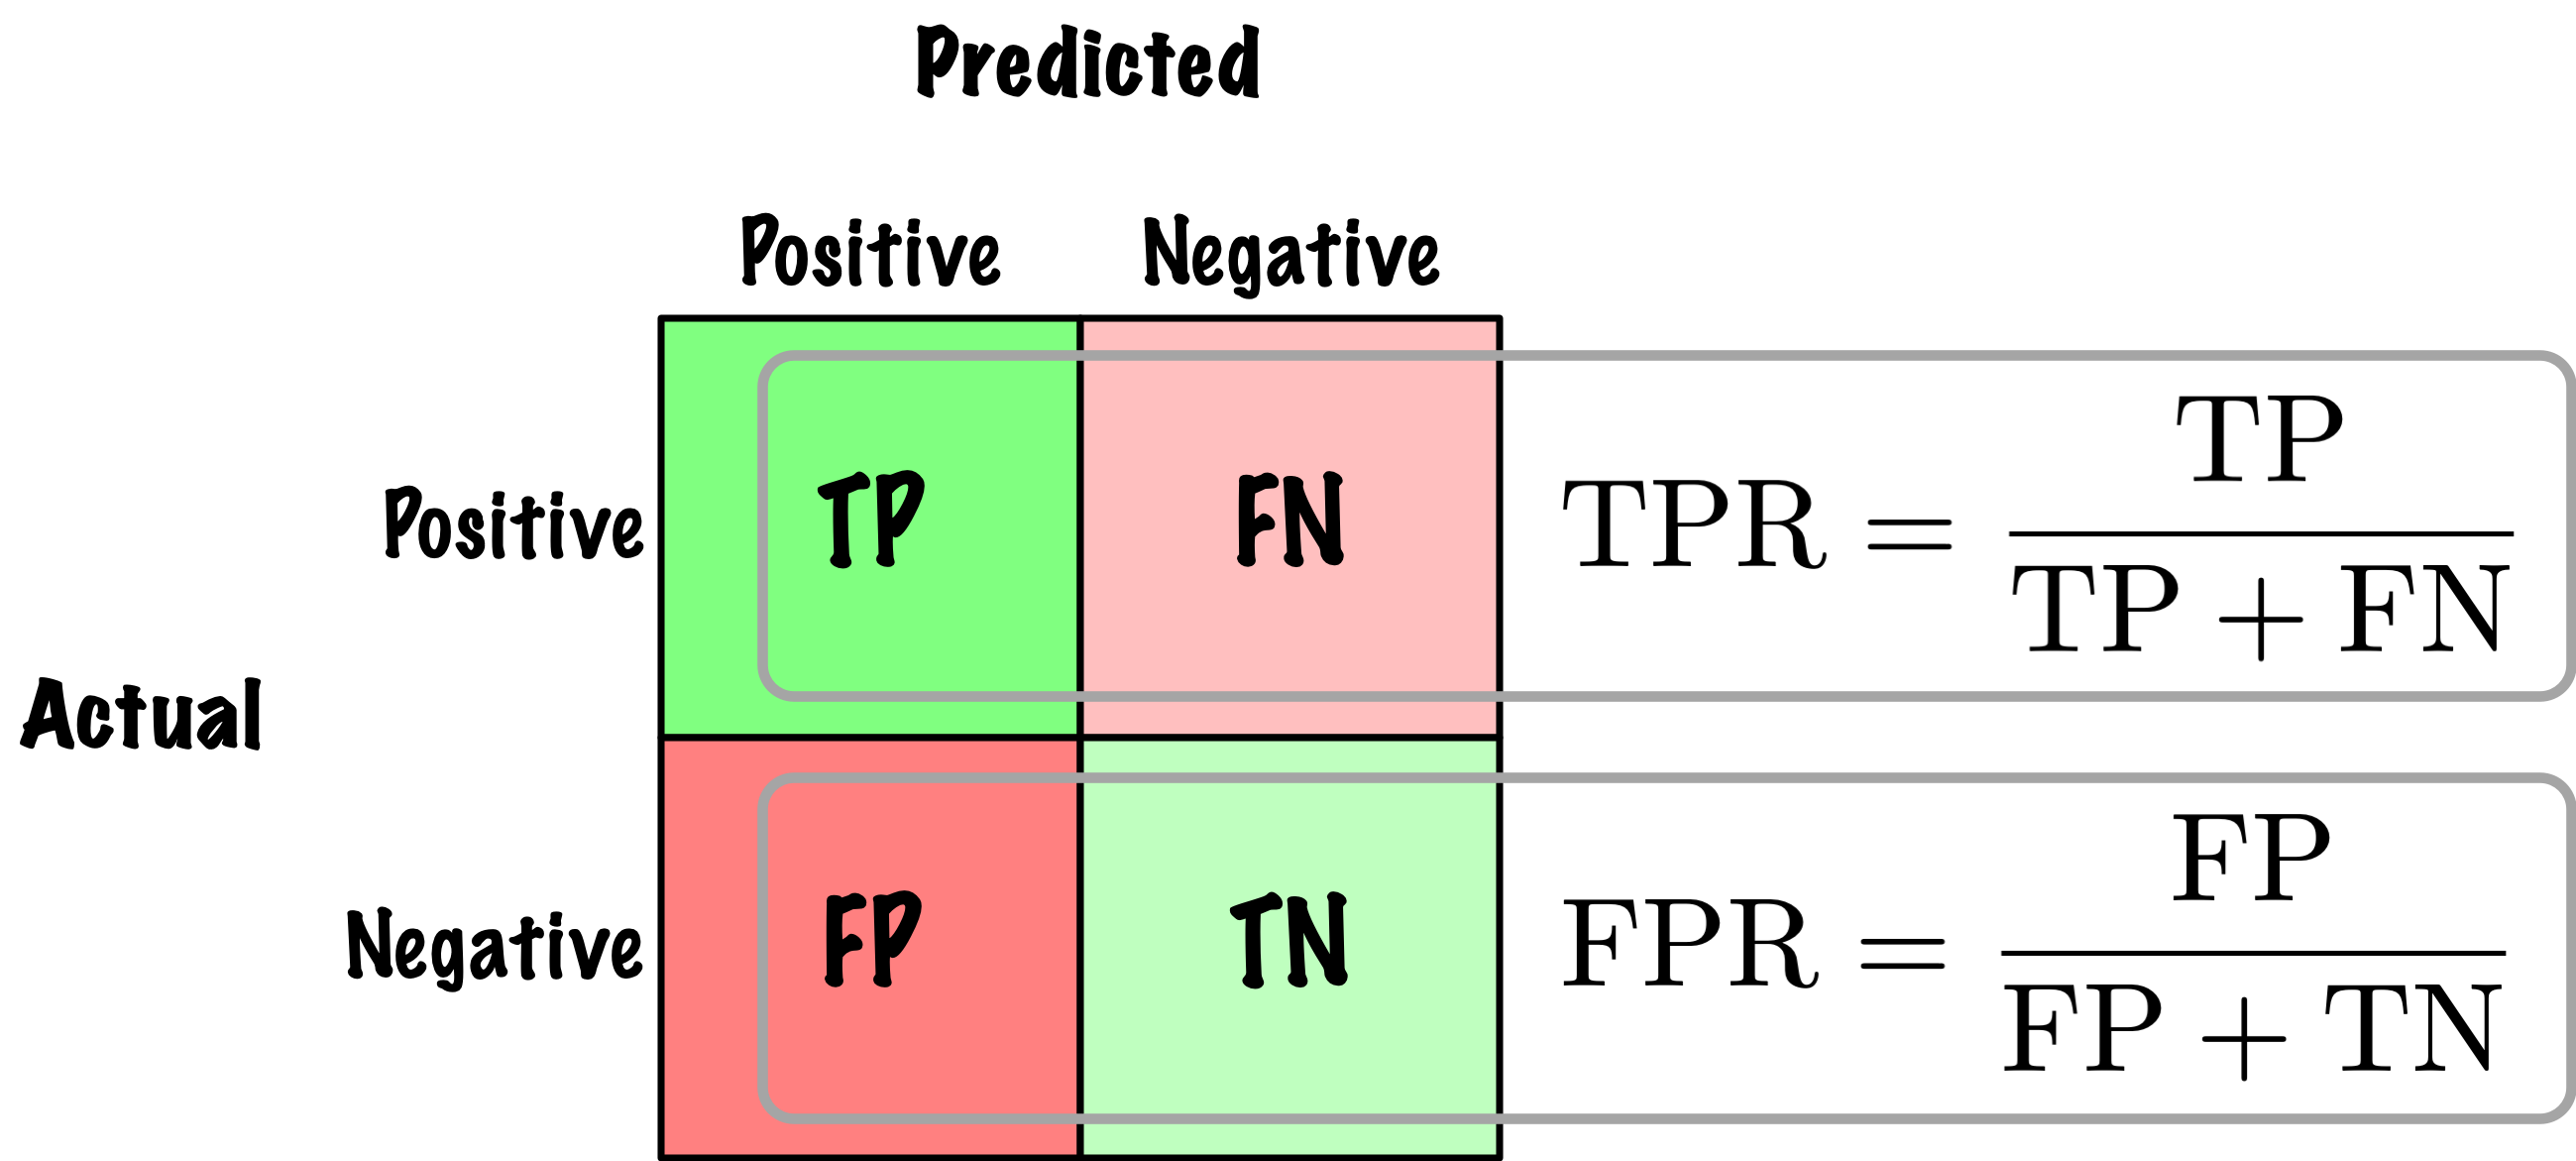

## ROC Curve

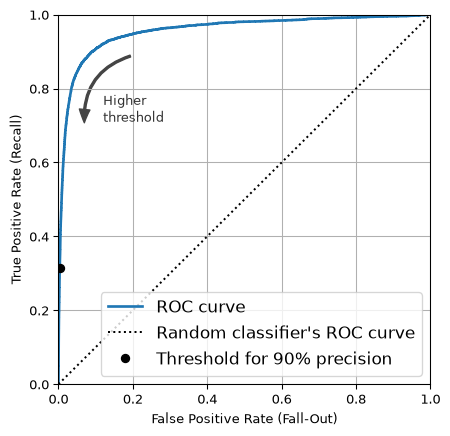

In [31]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

idx_for_threshold_at_90 = (
    thresholds <= threshold_for_90_precision
).argmax()
tpr_90 = tpr[idx_for_threshold_at_90]
fpr_90 = fpr[idx_for_threshold_at_90]

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

**Attribution:** <a
href="https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb"
class="external" data-icon="true">03_classification.ipynb</a>

Moving the threshold changes both the true-positive and false-positive
rates. The ROC curve records every resulting operating point. The curve
alone does not identify the best threshold because that choice depends
on the relative costs of false positives and false negatives.

## Score distributions and the ROC curve

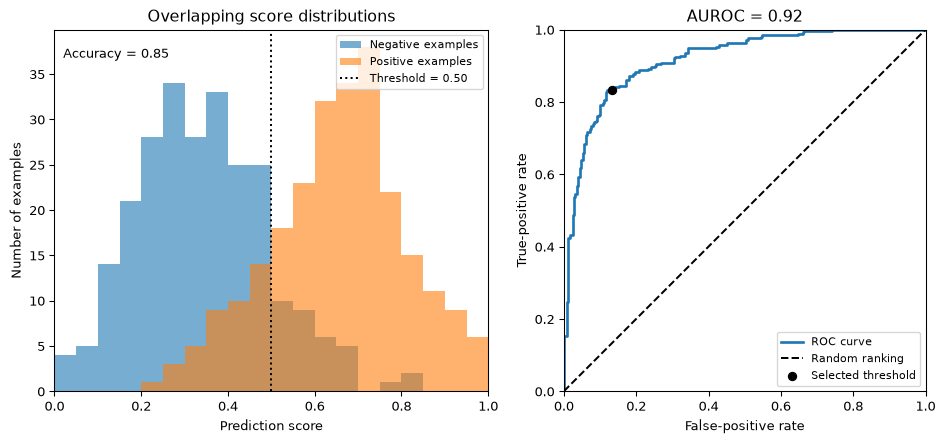

In [32]:
from sklearn.metrics import roc_auc_score, roc_curve

def plot_scores_and_roc(
    ax_scores,
    ax_roc,
    negative_scores,
    positive_scores,
    title,
    threshold=None,
):
    """Plot class score distributions beside their ROC curve."""
    labels = np.concatenate([
        np.zeros(len(negative_scores), dtype=int),
        np.ones(len(positive_scores), dtype=int),
    ])
    scores = np.concatenate([negative_scores, positive_scores])

    bins = np.linspace(0, 1, 21)
    ax_scores.hist(
        negative_scores,
        bins=bins,
        alpha=0.6,
        label="Negative examples",
    )
    ax_scores.hist(
        positive_scores,
        bins=bins,
        alpha=0.6,
        label="Positive examples",
    )
    ax_scores.set(
        title=title,
        xlabel="Prediction score",
        ylabel="Number of examples",
        xlim=(0, 1),
    )

    curve_fpr, curve_tpr, _ = roc_curve(labels, scores)
    area = roc_auc_score(labels, scores)
    ax_roc.plot(curve_fpr, curve_tpr, linewidth=2, label="ROC curve")
    ax_roc.plot([0, 1], [0, 1], "k--", label="Random ranking")
    ax_roc.set(
        title=f"AUROC = {area:.2f}",
        xlabel="False-positive rate",
        ylabel="True-positive rate",
        xlim=(0, 1),
        ylim=(0, 1),
    )
    ax_roc.set_aspect("equal", adjustable="box")

    if threshold is not None:
        predictions = (scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            labels,
            predictions,
            labels=[0, 1],
        ).ravel()
        point_fpr = fp / (fp + tn)
        point_tpr = tp / (tp + fn)
        accuracy = np.mean(predictions == labels)

        ax_scores.axvline(
            threshold,
            color="black",
            linestyle=":",
            label=f"Threshold = {threshold:.2f}",
        )
        ax_scores.text(
            0.02,
            0.95,
            f"Accuracy = {accuracy:.2f}",
            transform=ax_scores.transAxes,
            va="top",
        )
        ax_roc.scatter(
            point_fpr,
            point_tpr,
            color="black",
            zorder=3,
            label="Selected threshold",
        )

    ax_scores.legend(fontsize=8)
    ax_roc.legend(fontsize=8, loc="lower right")


roc_demo_rng = np.random.default_rng(seed)
roc_demo_size = 250
good_negative_scores = np.clip(
    roc_demo_rng.normal(0.35, 0.16, roc_demo_size),
    0,
    1,
)
good_positive_scores = np.clip(
    roc_demo_rng.normal(0.65, 0.16, roc_demo_size),
    0,
    1,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
plot_scores_and_roc(
    axes[0],
    axes[1],
    good_negative_scores,
    good_positive_scores,
    "Overlapping score distributions",
    threshold=0.50,
)
plt.show()

<a href="https://www.interactive-ml.com/roc-curve.html" class="external"
data-icon="true">Interactive ROC Curve</a>

The histogram shows the scores assigned to negative and positive
examples. For the marked threshold, examples to its right are predicted
positive. This produces one pair of false-positive and true-positive
rates, shown as the marked point on the ROC curve.

Moving the threshold changes the predicted labels, the confusion matrix,
accuracy, and the marked ROC operating point. It does not change AUROC
because the ordering of the scores remains unchanged. Sweeping the
threshold across all observed scores traces the full ROC curve.

The linked interactive demonstration animates this process and provides
excellent, good, poor, and random score distributions.

## Area under the ROC curve

The **area under the ROC curve (AUROC)** summarizes how well a score
ranks positive examples above negative examples.

- $\mathrm{AUROC}=1$: every positive example receives a higher score
  than every negative example.
- $\mathrm{AUROC}=0.5$: random ranking on average.
- $\mathrm{AUROC}<0.5$: the ranking is systematically reversed.

AUROC compares rankings across thresholds. It does not measure
probability calibration and does not choose an operating threshold.

With the usual half-credit convention for tied scores,

$$
\mathrm{AUROC}
= P(s^+ > s^-)
+ \frac{1}{2}P(s^+ = s^-),
$$

where $s^+$ and $s^-$ are the scores of randomly selected positive and
negative examples. This gives AUROC its probabilistic ranking
interpretation (Hanley and McNeil 1982). A classifier with AUROC below
0.5 may still contain useful information if its ranking is consistently
reversed.

ROC curves and AUROC are often used to compare how multiple classifiers
rank the same examples. A complete worked comparison using the Pima
diabetes dataset appears in the appendix.

## Perfect classifier

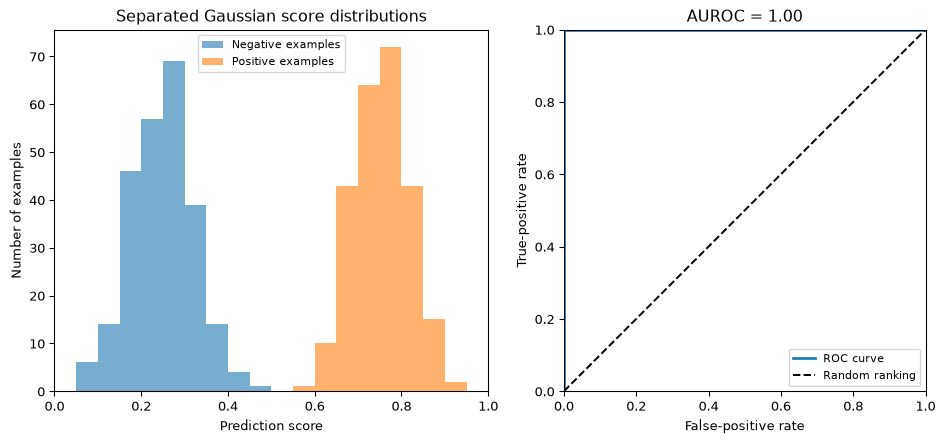

In [33]:
perfect_rng = np.random.default_rng(seed + 1)
perfect_negative_scores = np.clip(
    perfect_rng.normal(0.25, 0.07, roc_demo_size),
    0,
    1,
)
perfect_positive_scores = np.clip(
    perfect_rng.normal(0.75, 0.07, roc_demo_size),
    0,
    1,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
plot_scores_and_roc(
    axes[0],
    axes[1],
    perfect_negative_scores,
    perfect_positive_scores,
    "Separated Gaussian score distributions",
)
plt.show()

The two score distributions have Gaussian shapes and do not overlap in
this sample. Every positive example therefore receives a higher score
than every negative example, so AUROC equals 1.

## Random classifier

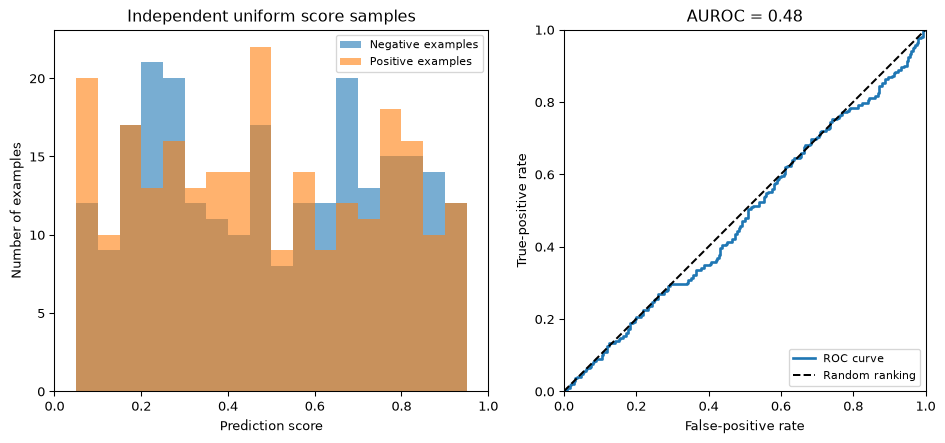

In [34]:
random_rng = np.random.default_rng(seed + 2)
random_negative_scores = random_rng.uniform(0.05, 0.95, roc_demo_size)
random_positive_scores = random_rng.uniform(0.05, 0.95, roc_demo_size)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
plot_scores_and_roc(
    axes[0],
    axes[1],
    random_negative_scores,
    random_positive_scores,
    "Independent uniform score samples",
)
plt.show()

Both classes draw scores independently from the same uniform
distribution. Their empirical histograms differ because of sampling
variation, but neither class tends to receive higher scores. AUROC is
therefore close to 0.5, and the empirical ROC curve fluctuates around
the random diagonal.

The all-positive rule occurs when the threshold lies below every score
and corresponds to the ROC endpoint $(1,1)$. The all-negative rule
corresponds to $(0,0)$. These are operating points produced by extreme
thresholds, whereas the diagonal represents random ranking across
thresholds.

## AUROC below 0.5

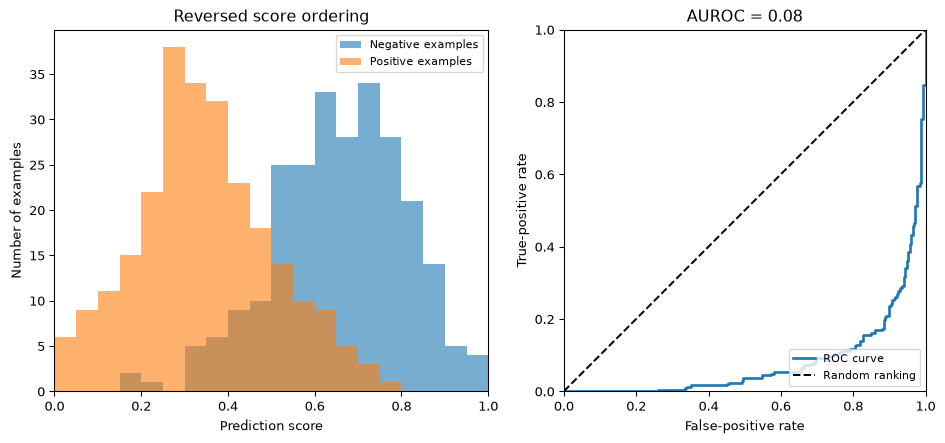

In [35]:
reversed_negative_scores = 1 - good_negative_scores
reversed_positive_scores = 1 - good_positive_scores

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
plot_scores_and_roc(
    axes[0],
    axes[1],
    reversed_negative_scores,
    reversed_positive_scores,
    "Reversed score ordering",
)
plt.show()

Before examining the figure, predict what the score histograms should
look like when AUROC is below 0.5.

The positive examples must tend to receive lower scores than the
negative examples. The ranking is therefore systematically reversed, and
the ROC curve falls below the random diagonal. Reversing the score
direction would transform an AUROC of $a$ into $1-a$, apart from the
treatment of ties.

## ROC or precision-recall?

- ROC uses **recall** and the **false-positive rate**, whose denominator
  contains all negative examples.
- With a very rare positive class, a large number of true negatives can
  make the false-positive rate appear small even when many predicted
  positives are wrong.
- A precision-recall curve focuses on the positive class and reveals how
  many positive predictions are correct.

Use the curve that matches the decision problem, and always inspect
class prevalence and an operating threshold.

ROC curves remain valid with imbalanced data, but their visual
interpretation can be optimistic when the negative class is much larger
than the positive class. Precision-recall curves often communicate
performance on a rare positive class more directly because precision
responds to the number of false-positive predictions (Davis and Goadrich
2006).

# Constructing ROC and AUROC

## Logistic Regression

- **Model**:

  $$
  h_\theta(x_i) = \sigma(\theta_0 + x_i^\top\theta)
  = \frac{1}{1+e^{-(\theta_0+x_i^\top\theta)}}
  $$

- **Prediction**:

  - Assign $y_i = 0$ if $h_\theta(x_i) < 0.5$.
  - Assign $y_i = 1$ if $h_\theta(x_i) \geq 0.5$.

- **Loss Function**: cross-entropy

$$
J(\theta) = -\frac{1}{N} \sum_{i=1}^{N}
\left[
y_i \log h_\theta(x_i)
+ (1-y_i) \log\left(1-h_\theta(x_i)\right)
\right]
$$

The confusion-matrix counts change systematically as the decision
threshold moves from 0 to 1.

At threshold = 0

- All predicted positive.
- TP: all actual positives are predicted positive, maximal TP.
- FP: all actual negatives are predicted positive, maximal FP.
- $\text{TPR} = 1$ (since $\text{TP} = P$, where $P$ is total
  positives).
- $\text{FPR} = 1$ (since $\text{FP} = N$, where $N$ is total
  negatives).
- ROC point = $(1,1)$.

As threshold increases from 0 to 1

- Fewer examples are predicted positive.
- TP decreases (some positives no longer exceed threshold).
- FP decreases (some negatives no longer exceed threshold).
- TPR decreases monotonically from 1 to 0.
- FPR decreases monotonically from 1 to 0.
- Curve traces down-left along the ROC space.

At threshold = 1

- All predicted negative.
- TP = 0, FP = 0.
- $\text{TPR} = 0$, $\text{FPR} = 0$.
- ROC point = $(0,0)$.

Summary intuition

- Lower threshold, more predicted positives, both TP and FP increase,
  both TPR and FPR increase.
- Higher threshold, more predicted negatives, both TP and FP decrease,
  both TPR and FPR decrease.
- The shape of the ROC curve depends on how well logistic regression
  separates positives from negatives:
- A perfect model climbs immediately towards $(0,1)$.
- Random ranking follows the diagonal on average.
- A useful ranking usually lies above the diagonal, while a
  systematically reversed ranking lies below it.

## Implementation: Logistic Regression

This implementation was presented in Lecture 6. It is repeated here so
that the notebook contains a working model for constructing the ROC
curve and computing AUROC.

In [36]:
import numpy as np

class LogisticRegression:

    """
    Binary logistic regression trained with batch gradient descent.

    Parameters
    ----------
    learning_rate : float, default=0.1
        Step size for gradient descent.
    max_iter : int, default=1000
        Number of gradient descent iterations.
    Notes
    -----
    - This implementation expects binary labels {0, 1}.
    - The intercept (bias) term is added internally during `fit`.
    - For simplicity, there is no regularization and no early stopping.
    """

    def __init__(
        self,
        learning_rate: float = 0.1,
        max_iter: int = 1000,
    ):
        if learning_rate <= 0:
            raise ValueError("learning_rate must be positive.")
        if max_iter <= 0:
            raise ValueError("max_iter must be positive.")

        self.learning_rate = learning_rate
        self.max_iter = max_iter

        # Attributes set after fitting
        self._theta = None
        self._loss_history = None
        self._n_features = None
        self._fitted = False

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        """Fit the model parameters using gradient descent."""
        X = self._as_2d_array(X, name="X")
        y = self._as_1d_array(y, name="y")

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                "X and y must contain the same number of examples."
            )
        self._check_binary_labels(y)

        n_examples, n_features = X.shape
        self._n_features = n_features
        Xb = self._add_intercept(X)

        # Zero initialization works because the objective is convex.
        self._theta = np.zeros(n_features + 1, dtype=float)
        self._loss_history = []

        for _ in range(self.max_iter):
            probabilities = self._sigmoid(Xb @ self._theta)
            gradient = (Xb.T @ (probabilities - y)) / n_examples
            self._theta -= self.learning_rate * gradient

            updated_probabilities = self._sigmoid(Xb @ self._theta)
            self._loss_history.append(
                self._bce_loss(updated_probabilities, y)
            )

        self._fitted = True
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Return predicted probabilities for the positive class."""
        self._ensure_fitted()
        X = self._as_2d_array(X, name="X")
        self._ensure_same_n_features(X)

        Xb = self._add_intercept(X)
        return self._sigmoid(Xb @ self._theta)

    def predict(
        self,
        X: np.ndarray,
        threshold: float = 0.5,
    ) -> np.ndarray:
        """Return class predictions using a probability threshold."""
        if not 0 <= threshold <= 1:
            raise ValueError("threshold must be between 0 and 1.")
        return (self.predict_proba(X) >= threshold).astype(int)

    @property
    def intercept_(self) -> float:
        """Return the fitted intercept."""
        self._ensure_fitted()
        return float(self._theta[0])

    @property
    def coef_(self) -> np.ndarray:
        """Return a copy of the fitted feature coefficients."""
        self._ensure_fitted()
        return self._theta[1:].copy()

    def get_loss_history(self) -> list:
        """Return a copy of the loss values collected during fitting."""
        self._ensure_fitted()
        return list(self._loss_history)

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        """Compute the sigmoid without numerical overflow."""
        z = np.asarray(z, dtype=float)
        result = np.empty_like(z)
        positive = z >= 0
        result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
        exp_z = np.exp(z[~positive])
        result[~positive] = exp_z / (1.0 + exp_z)
        return result

    @staticmethod
    def _bce_loss(probabilities: np.ndarray, y: np.ndarray) -> float:
        probabilities = np.clip(probabilities, 1e-12, 1.0 - 1e-12)
        return float(
            -np.mean(
                y * np.log(probabilities)
                + (1 - y) * np.log(1 - probabilities)
            )
        )

    @staticmethod
    def _as_2d_array(X, name="X") -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            message = (
                f"{name} must be a 2D array of shape "
                "(n_samples, n_features)."
            )
            raise ValueError(message)
        return X

    @staticmethod
    def _as_1d_array(y, name="y") -> np.ndarray:
        y = np.asarray(y, dtype=float)
        if y.ndim != 1:
            message = f"{name} must have shape (n_samples,)."
            raise ValueError(message)
        return y

    @staticmethod
    def _check_binary_labels(y: np.ndarray) -> None:
        if not np.array_equal(np.unique(y), np.array([0.0, 1.0])):
            raise ValueError(
                "y must contain both binary labels 0 and 1."
            )

    @staticmethod
    def _add_intercept(X: np.ndarray) -> np.ndarray:
        return np.column_stack([np.ones(X.shape[0]), X])

    def _ensure_fitted(self) -> None:
        if not self._fitted or self._theta is None:
            raise RuntimeError(
                "Call fit(X, y) before using the fitted model."
            )

    def _ensure_same_n_features(self, X: np.ndarray) -> None:
        if X.shape[1] != self._n_features:
            message = (
                f"X has {X.shape[1]} features; "
                f"expected {self._n_features}."
            )
            raise ValueError(message)

## Implementation: ROC

In [37]:
def compute_roc_curve(y_true, y_scores):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    thresholds = np.r_[np.inf, np.sort(np.unique(y_scores))[::-1]]
    tpr_list, fpr_list = [], []

    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        tpr_list.append(tp / (tp + fn)) # true positive rate
        fpr_list.append(fp / (fp + tn)) # false positive rate

    return np.array(fpr_list), np.array(tpr_list), thresholds

## Implementation: AUROC

In [38]:
def compute_auroc(fpr, tpr):

    return np.trapezoid(tpr, fpr)

The **trapezoidal rule** approximates an integral by dividing the region
under a curve into trapezoids. Here, it computes the area under the
piecewise-linear ROC curve.

## Example: Generate Data + Predictions

In [39]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=5,
    random_state=seed,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=seed,
    stratify=y,
)

model = LogisticRegression(learning_rate=0.1, max_iter=500)
model.fit(X_train, y_train)

## Example: Plot

Manual AUROC:       0.938
scikit-learn AUROC: 0.938

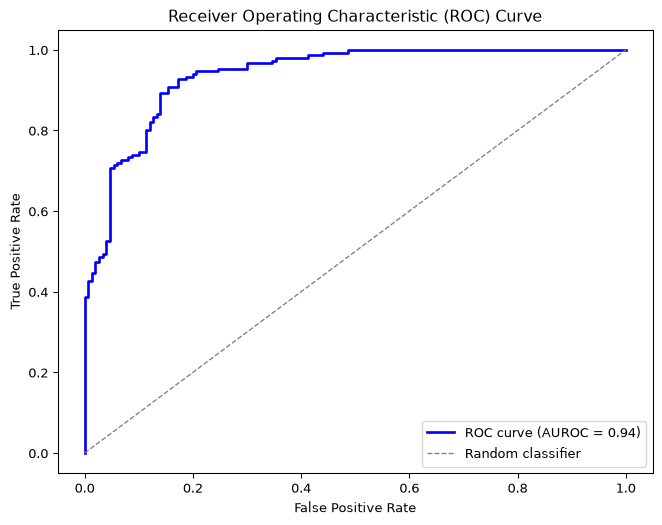

In [40]:
# Compute predicted probabilities for the positive class on the test set
y_probs = model.predict_proba(X_test)

# Compute the ROC curve (FPR and TPR for each threshold)
fpr, tpr, thresholds = compute_roc_curve(y_test, y_probs)
auroc_value = compute_auroc(fpr, tpr)

from sklearn.metrics import roc_auc_score
sklearn_auc = roc_auc_score(y_test, y_probs)

print(f"Manual AUROC:       {auroc_value:.3f}")
print(f"scikit-learn AUROC: {sklearn_auc:.3f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="blue",
    lw=2,
    label=f"ROC curve (AUROC = {auroc_value:.2f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    lw=1,
    linestyle="--",
    label="Random classifier",
)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## See also

- <a
  href="https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html"
  class="external" data-icon="true">Multiclass Receiver Operating
  Characteristic (ROC)</a> presents examples of micro- and macro-average
  curves.

------------------------------------------------------------------------

<https://youtu.be/4jRBRDbJemM>

The video above by StatQuest, Josh Starmer, offers a detailed,
step-by-step guide on how to construct and analyze Receiver Operating
Characteristic (ROC) curves.

# Closing Material

## Summary

- Derived binary and one-vs-rest counts from **confusion matrices**.
- Computed and interpreted **accuracy**, **precision**, **recall**, and
  the **$F_1$ score**, including the limitations of accuracy under class
  imbalance.
- Distinguished **micro averaging**, which gives each prediction equal
  weight, from **macro averaging**, which gives each class equal weight.
- Related the decision threshold to the **precision-recall trade-off**
  and to operating points on the **ROC curve**.
- Interpreted **AUROC** as a measure of score ranking. AUROC does not
  assess probability calibration or select a decision threshold.

## Key references

- Sokolova and Lapalme (2009) systematically analyzes classification
  performance measures across binary, multiclass, and multilabel tasks.
- Hanley and McNeil (1982) establishes the probabilistic ranking
  interpretation of the area under an ROC curve.
- Davis and Goadrich (2006) explains the relationship between ROC and
  precision-recall curves, including the effect of skewed class
  distributions.

## Evaluating Learning Algorithms

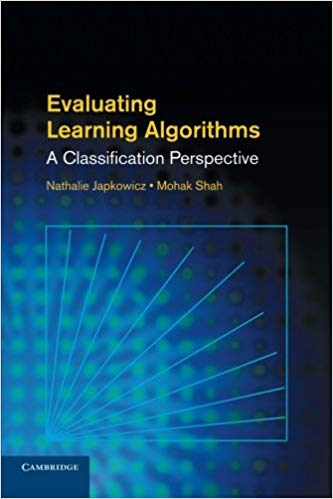

- This <a
  href="https://www.cambridge.org/core/books/evaluating-learning-algorithms/3CB22D16AB609D1770C24CA2CB5A11BF"
  class="external" data-icon="true">book</a> examines the evaluation
  process, with particular attention to classification algorithms
  (Japkowicz and Shah 2011).

- <a href="https://www.american.edu/cas/faculty/japkowic.cfm"
  class="external" data-icon="true">Nathalie Japkowicz</a> previously
  served as a professor at the University of Ottawa.

- <a href="http://www.mohakshah.com" class="external"
  data-icon="true">Mohak Shah</a> earned his PhD from the University of
  Ottawa and has held several industry roles in AI and machine learning.

## Next lecture

- We will examine cross-validation and hyperparameter tuning.

## References

Davis, Jesse, and Mark Goadrich. 2006. “<span class="nocase">The
relationship between Precision-Recall and ROC curves</span>.”
*Proceedings of the 23rd International Conference on Machine Learning -
ICML ’06*, 233–40. <https://doi.org/10.1145/1143844.1143874>.

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3rd ed. O’Reilly Media, Inc.

Hanley, J A, and B J McNeil. 1982. “<span class="nocase">The meaning and
use of the area under a receiver operating characteristic (ROC)
curve.</span>” *Radiology* 143 (1): 29–36.
<https://doi.org/10.1148/radiology.143.1.7063747>.

Japkowicz, Nathalie, and Mohak Shah. 2011. *Evaluating Learning
Algorithms: A Classification Perspective*. Cambridge University Press.

Knowler, William C., David J. Pettitt, Peter J. Savage, and Peter H.
Bennett. 1981. “Diabetes Incidence in Pima Indians: Contributions of
Obesity and Parental Diabetes.” *American Journal of Epidemiology* 113
2: 144–56. <https://api.semanticscholar.org/CorpusID:25209675>.

Russell, Stuart, and Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4th ed. Pearson. <http://aima.cs.berkeley.edu/>.

Sokolova, Marina, and Guy Lapalme. 2009. “<span class="nocase">A
systematic analysis of performance measures for classification
tasks</span>.” *Information Processing and Management* 45 (4): 427–37.
<https://doi.org/10.1016/j.ipm.2009.03.002>.

Unceta, Irene, Paula Subı́as-Beltrán, and Oriol Pujol. 2026. “The
Epistemic Debt of Generative AI.” *Nature Machine Intelligence* 8 (9):
1328–30. <https://doi.org/10.1038/s42256-026-01294-w>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

School of Electrical Engineering and **Computer Science** (EE**CS**)

University of Ottawa

# Appendix: 20 Newsgroups

## Worked example: 20 Newsgroups

Using the <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html#sklearn.datasets.fetch_20newsgroups"
class="external" data-icon="true">20 Newsgroups text dataset</a> from
<a href="https://scikit-learn.org" class="external"
data-icon="true">scikit-learn</a>.

The complete dataset contains approximately 18,000 newsgroup posts from
20 topics. This example uses four topics.

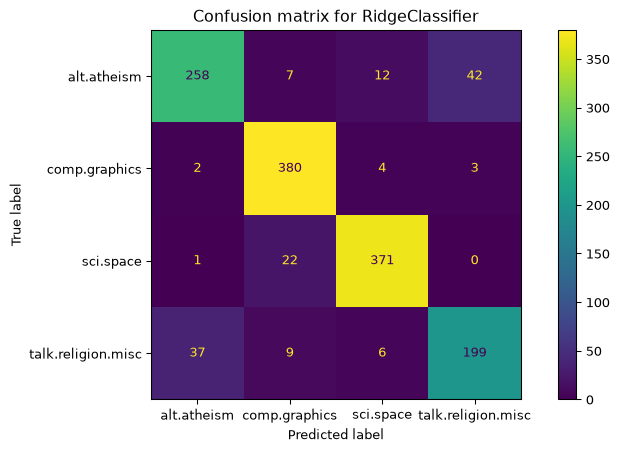

In [41]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifier

categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]

data_train = fetch_20newsgroups(
    subset="train",
    categories=categories,
    shuffle=True,
    random_state=seed,
)
data_test = fetch_20newsgroups(
    subset="test",
    categories=categories,
    shuffle=True,
    random_state=seed,
)

vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
X_train = vectorizer.fit_transform(data_train.data)
X_test = vectorizer.transform(data_test.data)
y_train = data_train.target
y_test = data_test.target
target_names = data_train.target_names

clf = RidgeClassifier(tol=1e-2, solver="sparse_cg")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.xaxis.set_ticklabels(target_names)
ax.yaxis.set_ticklabels(target_names)
ax.set_title(f"Confusion matrix for {clf.__class__.__name__}")
plt.show()

## Confusion matrix as an array

In [42]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[258,   7,  12,  42],
       [  2, 380,   4,   3],
       [  1,  22, 371,   0],
       [ 37,   9,   6, 199]])

## One-vs-rest counts

In [43]:
def true_positive(cm, i):
    return cm[i, i]

def false_positive(cm, i):
    return np.sum(cm[:, i]) - cm[i, i]

def false_negative(cm, i):
    return np.sum(cm[i, :]) - cm[i, i]

def true_negative(cm, i):
    n_examples = cm.sum()
    tp = true_positive(cm, i)
    fp = false_positive(cm, i)
    fn = false_negative(cm, i)
    return n_examples - (tp + fp + fn)

## Micro and macro precision

In [44]:
def precision_micro(cm):
    _, n_classes = cm.shape
    tp = fp = 0
    for i in range(n_classes):
        tp += true_positive(cm, i)
        fp += false_positive(cm, i)
    return tp / (tp + fp)

def precision_macro(cm):
    _, n_classes = cm.shape
    precision_sum = 0
    for i in range(n_classes):
        tp = true_positive(cm, i)
        fp = false_positive(cm, i)
        precision_sum += tp / (tp + fp)
    return precision_sum / n_classes

print(f"Micro precision: {precision_micro(cm):.3f}")
print(f"Macro precision: {precision_macro(cm):.3f}")

Micro precision: 0.893
Macro precision: 0.884

## Micro-average precision

$$
  \frac{(258+380+371+199)}{(258+380+371+199)+(40+38+22+45)}
$$ where

- 40 = 2 + 1 + 37
- 38 = 7 + 22 + 9
- 22 = 12 + 4 + 6
- 45 = 42 + 3 + 0

89.28307465 %

## Macro-average precision

- $\mathrm{Precision}_0 = \frac{258}{258+(2+1+37)} = 0.8657718121$
- $\mathrm{Precision}_1 = \frac{380}{380+(7+22+9)} = 0.9090909091$
- $\mathrm{Precision}_2 = \frac{371}{371+(12+4+6)} = 0.9440203562$
- $\mathrm{Precision}_3 = \frac{199}{199+(42+3+0)} = 0.8155737705$

$\mathrm{Precision}_{\mathrm{macro}} = \frac{0.8657718121 + 0.9090909091 + 0.9440203562 + 0.8155737705}{4}$

88.3614212 %

## Micro and macro recall

In [45]:
def recall_micro(cm):
    _, n_classes = cm.shape
    tp = fn = 0
    for i in range(n_classes):
        tp += true_positive(cm, i)
        fn += false_negative(cm, i)
    return tp / (tp + fn)

def recall_macro(cm):
    _, n_classes = cm.shape
    recall_sum = 0
    for i in range(n_classes):
        tp = true_positive(cm, i)
        fn = false_negative(cm, i)
        recall_sum += tp / (tp + fn)
    return recall_sum / n_classes

print(f"Micro recall: {recall_micro(cm):.3f}")
print(f"Macro recall: {recall_macro(cm):.3f}")

Micro recall: 0.893
Macro recall: 0.880

# Appendix: Comparing Classifier Scores

## OpenML dataset

>  **<a href="https://www.openml.org" class="external"
> data-icon="true">www.openml.org</a>**
>
> OpenML is an open platform for sharing datasets, algorithms, and
> experiments that support reproducible machine learning.

. . .

In [46]:
diabetes = fetch_openml(name='diabetes', version=1)
print(diabetes.DESCR)

The Pima diabetes dataset contains 768 examples and eight numerical
features. It supports a compact demonstration of score-based evaluation,
but its age, population, and data-quality limitations must be considered
before drawing medical conclusions.

## Pima Indians Diabetes Dataset

In [47]:
# Load the Pima Indians Diabetes dataset
pima = fetch_openml(data_id=37, as_frame=True)

# Extract the features and target
X = pima.data
y = pima.target

# Encode the two target labels as 0 and 1
y = y.map({'tested_negative': 0, 'tested_positive': 1})

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=seed,
    stratify=y,
)

<a
href="https://www.openml.org/search?type=data&amp;sort=version&amp;status=any&amp;order=asc&amp;exact_name=diabetes&amp;id=37"
class="external" data-icon="true">Pima Indians Diabetes Dataset</a> as
described in Knowler et al. (1981)
\[<a href="https://pubmed.ncbi.nlm.nih.gov/7468572/" class="external"
data-icon="true">PubMed</a>\].

## Comparing Multiple Classifiers

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Comparing Multiple Classifiers

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

dt = DecisionTreeClassifier(random_state=seed)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=seed)
rf.fit(X_train, y_train)

The two distance- and gradient-based classifiers use standardized
features. The tree-based classifiers use the original feature values.

## ROC curves and AUROC

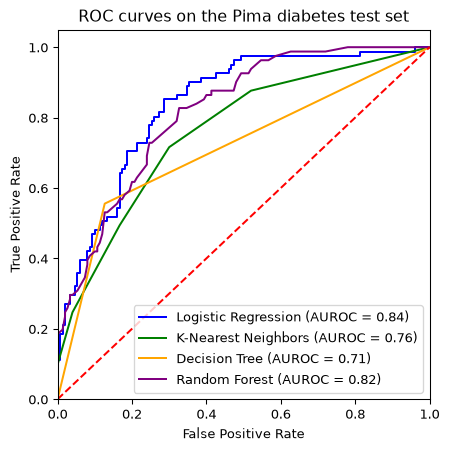

In [50]:
from sklearn.metrics import roc_auc_score

y_pred_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
y_pred_prob_dt = dt.predict_proba(X_test)[:, 1]
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

# Compute AUROC scores
auc_lr = roc_auc_score(y_test, y_pred_prob_lr)
auc_knn = roc_auc_score(y_test, y_pred_prob_knn)
auc_dt = roc_auc_score(y_test, y_pred_prob_dt)
auc_rf = roc_auc_score(y_test, y_pred_prob_rf)

# Plot ROC curves
plt.figure(figsize=(5, 5))
plt.plot(
    fpr_lr,
    tpr_lr,
    color="blue",
    label=f"Logistic Regression (AUROC = {auc_lr:.2f})",
)
plt.plot(
    fpr_knn,
    tpr_knn,
    color="green",
    label=f"K-Nearest Neighbors (AUROC = {auc_knn:.2f})",
)
plt.plot(
    fpr_dt,
    tpr_dt,
    color="orange",
    label=f"Decision Tree (AUROC = {auc_dt:.2f})",
)
plt.plot(
    fpr_rf,
    tpr_rf,
    color="purple",
    label=f"Random Forest (AUROC = {auc_rf:.2f})",
)
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves on the Pima diabetes test set")
plt.legend(loc="lower right")
plt.show()

ROC curves provide a visual representation of a classifier’s performance
across **all possible thresholds**. By plotting the True Positive Rate
(TPR) against the False Positive Rate (FPR), they reveal the trade-off
between sensitivity (recall) and specificity.

Unlike accuracy, an ROC curve summarizes score rankings across many
thresholds. This worked example describes the fitted models on one
held-out set. It is not a model-selection procedure. Lecture 8 separates
validation from final testing.